# IT3051 – Fundamentals of Data Mining | Mini Project 2026
## Stage 3 – Data Understanding & Exploratory Data Analysis (EDA)
**Group:** Mine4Data (DS.Y3S2.01.01) · **Project:** Airbnb Listing Price Prediction · **Dataset:** Airbnb Price Dataset (Rana, Kaggle), `Airbnb_Data.csv`

**Problem.** New and existing Airbnb hosts need a data-driven nightly-price recommendation. We predict **`log_price`** (natural log of the nightly price in USD) from property, host, location, amenity and policy attributes. This is a **supervised regression** task.

**Goal of this notebook.** Understand the data *before* any preprocessing, and document every observation that drives a later preprocessing or modelling decision. It follows the Stage 3 checklist and goes beyond it:

| # | Section | Stage 3 requirement covered |
|---|---|---|
| 1 | Setup & loading | – |
| 2 | Structure & variable types | structure, meaning, variable types |
| 3 | Missing values | missing values |
| 4 | Duplicates | duplicated records |
| 5 | Invalid & inconsistent values | unusual observations |
| 6 | Target variable (`log_price`) | distribution, "imbalance" for regression |
| 7 | Numeric features – distributions & outliers | outliers |
| 8 | Categorical & boolean features | distributions, rare categories, cardinality |
| 9 | Feature ↔ target relationships | relationships |
| 10 | Multicollinearity & interactions | relationships |
| 11 | Geospatial analysis | *beyond checklist* |
| 12 | Amenities (text-list column) | *beyond checklist* |
| 13 | Dates & host tenure | *beyond checklist* |
| 14 | Free-text columns | justifies dropping columns |
| 15 | Target balance across groups | class imbalance (regression version) |
| 16 | Data leakage | leakage and how we prevent it |
| 17 | Summary: findings → preprocessing decisions | observations that drive Stage 4 |

> **Rule followed throughout:** this notebook only *inspects* data. Type parsing (e.g. `"t"` → `True`) is done on a working copy so we can analyse the data. We do **no imputation, encoding, scaling or row removal** here. Those steps are fitted on the training split only, in the preprocessing notebook, to avoid leakage (see Section 16).

## 1. Setup & data loading

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.3f}".format)

FIG_DIR = Path("figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chart palette: one main hue (blue) for magnitude, fixed categorical order, recessive axes.
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, BLUE_LIGHT, ORANGE, AQUA, RED = "#2a78d6", "#86b6ef", "#eb6834", "#1baf7a", "#e34948"
CAT = [BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", RED]
ROOM_COLORS = {"Entire home/apt": BLUE, "Private room": ORANGE, "Shared room": AQUA}
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list(
    "div_red_blue", ["#b3302f", "#e66767", "#f4b9b8", "#f0efec", "#b7d3f6", "#5598e7", "#184f95"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "text.color": INK,
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False, "axes.prop_cycle": plt.cycler(color=CAT),
})
BOX_KW = dict(color=BLUE_LIGHT, linewidth=1, fliersize=1.2,
              flierprops=dict(markerfacecolor=INK2, markeredgecolor="none", alpha=0.3),
              medianprops=dict(color="#0d366b", linewidth=2))

def save(fig, name):
    # Save every figure so it can go straight into the report / viva slides.
    fig.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

In [2]:
raw = pd.read_csv("Airbnb_Data.csv")   # untouched copy of the source file
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
print(f"Memory: {raw.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
raw.head(3)

Rows: 74,111   Columns: 29


Memory: 171.5 MB


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.011,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.000,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.697,-73.992,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.000,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.000,1.000
1,6304928,5.130,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.000,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766,-73.989,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.000,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.000,3.000
2,7919400,4.977,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.000,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808,-73.944,The Garden Oasis,Harlem,10,92.000,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.000,3.000


## 2. Structure & variable types

In [3]:
VAR_TYPES = {
    "Identifier":            ["id"],
    "Target":                ["log_price"],
    "Numeric – discrete":    ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews"],
    "Numeric – continuous":  ["review_scores_rating", "host_response_rate", "latitude", "longitude"],
    "Categorical – nominal": ["property_type", "room_type", "bed_type", "city", "neighbourhood", "zipcode"],
    "Categorical – ordinal": ["cancellation_policy"],
    "Boolean":               ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"],
    "Date":                  ["first_review", "last_review", "host_since"],
    "Text / list":           ["amenities", "description", "name", "thumbnail_url"],
}
assert sum(len(v) for v in VAR_TYPES.values()) == raw.shape[1]

rows = []
for vtype, cols in VAR_TYPES.items():
    for c in cols:
        s = raw[c]
        rows.append({"column": c, "semantic type": vtype, "stored dtype": str(s.dtype),
                     "unique": s.nunique(), "missing %": s.isna().mean() * 100,
                     "example": str(s.dropna().iloc[0])[:45]})
schema = pd.DataFrame(rows).set_index("column")
schema

,semantic type,stored dtype,unique,missing %,example
column,,,,,
id,Identifier,int64,74111,0.000,6901257
log_price,Target,float64,767,0.000,5.010635294096256
accommodates,Numeric – discrete,int64,16,0.000,3
bathrooms,Numeric – discrete,float64,17,0.270,1.0
bedrooms,Numeric – discrete,float64,11,0.123,1.0
beds,Numeric – discrete,float64,18,0.177,1.0
number_of_reviews,Numeric – discrete,int64,371,0.000,2
review_scores_rating,Numeric – continuous,float64,54,22.563,100.0
host_response_rate,Numeric – continuous,str,80,24.691,100%


**Observations**
- **29 columns** in 9 semantic groups. The **stored dtype often does not match the meaning**, so these columns must be converted before analysis or modelling:
  - `host_response_rate` is text such as `"100%"`, but it is really a number.
  - `host_has_profile_pic`, `host_identity_verified` and `instant_bookable` store `"t"`/`"f"` text. Only `cleaning_fee` is already a true boolean.
  - `first_review`, `last_review` and `host_since` are date strings.
  - `zipcode` is text and is **not** numeric: it is an identifier with inconsistent formatting (Section 5).
  - `amenities` is a stringified set (`{TV,"Wireless Internet",...}`) that must be parsed into multiple binary features.
- `cancellation_policy` is **ordinal** (flexible < moderate < strict < super_strict_30 < super_strict_60), so ordinal encoding is a sensible option for it.
- `neighbourhood` (619 levels) and `zipcode` (769 raw levels) are **high-cardinality** categoricals. One-hot encoding them would add hundreds of sparse columns, so they need target/frequency encoding.

In [4]:
# Working copy with parsed types (NO imputation / removal – analysis only)
df = raw.copy()
for c in ["host_has_profile_pic", "host_identity_verified", "instant_bookable"]:
    df[c] = df[c].map({"t": True, "f": False})
df["host_response_rate"] = pd.to_numeric(df["host_response_rate"].str.rstrip("%"), errors="coerce")
for c in ["first_review", "last_review", "host_since"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
df["price"] = np.exp(df["log_price"])          # back-transformed target, for interpretation only

NUM_COLS = ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews",
            "review_scores_rating", "host_response_rate"]
df[NUM_COLS + ["log_price", "price"]].describe(percentiles=[.01, .25, .5, .75, .99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
accommodates,"74,111.000",3.155,2.154,1.000,1.000,2.000,2.000,4.000,12.000,16.000
bathrooms,"73,911.000",1.235,0.582,0.000,1.000,1.000,1.000,1.000,3.500,8.000
bedrooms,"74,020.000",1.266,0.852,0.000,0.000,1.000,1.000,1.000,4.000,10.000
beds,"73,980.000",1.711,1.254,0.000,1.000,1.000,1.000,2.000,6.000,18.000
number_of_reviews,"74,111.000",20.901,37.829,0.000,0.000,1.000,6.000,23.000,178.000,605.000
review_scores_rating,"57,389.000",94.067,7.837,20.000,60.000,92.000,96.000,100.000,100.000,100.000
host_response_rate,"55,812.000",94.352,16.342,0.000,0.000,100.000,100.000,100.000,100.000,100.000
log_price,"74,111.000",4.782,0.717,0.000,3.367,4.317,4.710,5.220,6.894,7.600
price,"74,111.000",160.371,168.580,1.000,29.000,75.000,111.000,185.000,986.800,"1,999.000"


**Observations**
- The median listing sleeps **2**, with **1** bedroom, **1** bed and **1** bathroom. The data is dominated by small units.
- `number_of_reviews` is extremely right-skewed: the median is 6, the 99th percentile is 178, and the maximum is 605.
- `review_scores_rating` is **bunched at the top**: the median is 96 and the 75th percentile is 100. The scale is effectively 80–100, so this feature has little spread.
- `host_response_rate`: at least 75% of the non-missing values are 100%, so it is heavily concentrated at the maximum.
- The minimum `log_price` is **0.0, i.e. a $1/night listing**. The maximum is **$1,999**. We investigate both extremes in Sections 5–6.

## 3. Missing values

,missing,missing %,semantic type
host_response_rate,18299,24.691,Numeric – continuous
review_scores_rating,16722,22.563,Numeric – continuous
first_review,15864,21.406,Date
last_review,15827,21.356,Date
thumbnail_url,8216,11.086,Text / list
neighbourhood,6872,9.273,Categorical – nominal
zipcode,966,1.303,Categorical – nominal
bathrooms,200,0.270,Numeric – discrete
host_has_profile_pic,188,0.254,Boolean
host_identity_verified,188,0.254,Boolean


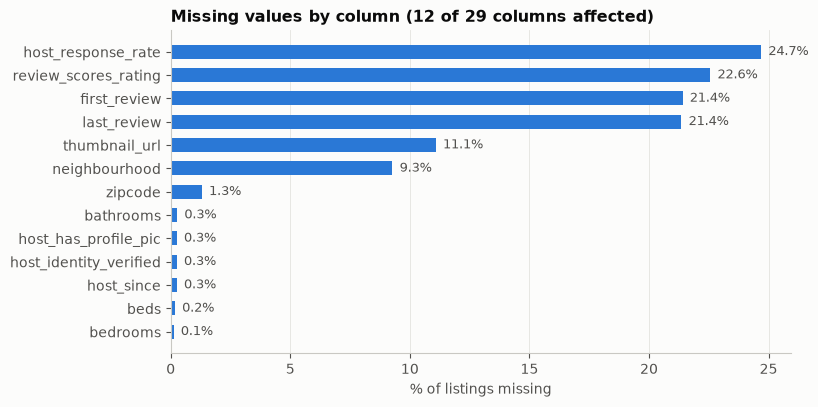

In [5]:
miss = (pd.DataFrame({"missing": raw.isna().sum(), "missing %": raw.isna().mean() * 100})
          .query("missing > 0").sort_values("missing", ascending=False))
miss["semantic type"] = [schema.loc[c, "semantic type"] for c in miss.index]
display(miss)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(miss.index[::-1], miss["missing %"][::-1], color=BLUE, height=0.6)
for y, v in enumerate(miss["missing %"][::-1]):
    ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9, color=INK2)
ax.set_xlabel("% of listings missing"); ax.set_title("Missing values by column (12 of 29 columns affected)")
ax.grid(axis="y", visible=False)
save(fig, "03_missing_values")

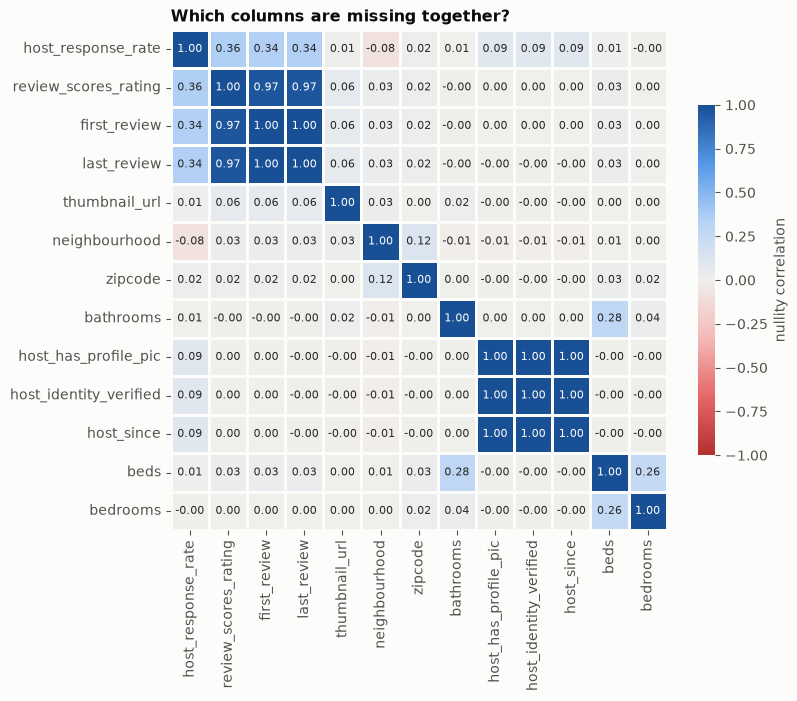

In [6]:
# Do columns go missing TOGETHER?  Correlation of the missing-indicator matrix (nullity correlation)
null_corr = raw[miss.index].isna().astype(int).corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(null_corr, cmap=DIVERGING, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=2, linecolor=SURFACE, cbar_kws={"shrink": .7, "label": "nullity correlation"}, ax=ax)
ax.set_title("Which columns are missing together?")
save(fig, "03_nullity_correlation")

In [7]:
# Missing-mechanism checks
no_reviews = df["number_of_reviews"] == 0
print("review_scores_rating missing vs number_of_reviews == 0")
display(pd.crosstab(df["review_scores_rating"].isna().rename("rating missing"),
                    no_reviews.rename("0 reviews"), margins=True))
print("first_review missing & 0 reviews agree for "
      f"{(df['first_review'].isna() == no_reviews).mean():.2%} of rows")
print("Rows with the 3 host columns all missing:",
      df[["host_since", "host_has_profile_pic", "host_identity_verified"]].isna().all(axis=1).sum())
print("\n% of neighbourhood missing, per city")
display((df.groupby("city")["neighbourhood"].apply(lambda s: s.isna().mean() * 100)
           .sort_values(ascending=False).to_frame("neighbourhood missing %")))

review_scores_rating missing vs number_of_reviews == 0


0 reviews,False,True,All
rating missing,,,
False,57389,0,57389
True,903,15819,16722
All,58292,15819,74111


first_review missing & 0 reviews agree for 99.94% of rows
Rows with the 3 host columns all missing: 188

% of neighbourhood missing, per city


,neighbourhood missing %
city,
LA,24.077
Chicago,17.666
DC,13.977
SF,0.093
NYC,0.025
Boston,0.000


In [8]:
# Is "missing" itself informative about the target?  (Mann-Whitney U test, log_price missing vs present)
rows = []
for c in miss.index:
    m = raw[c].isna()
    a, b = df.loc[m, "log_price"], df.loc[~m, "log_price"]
    rows.append({"column": c, "n missing": m.sum(),
                 "median $ | missing": np.exp(a.median()), "median $ | present": np.exp(b.median()),
                 "diff in mean log_price": a.mean() - b.mean(),
                 "Mann-Whitney p": stats.mannwhitneyu(a, b).pvalue})
miss_vs_target = pd.DataFrame(rows).set_index("column")
miss_vs_target

,n missing,median $ | missing,median $ | present,diff in mean log_price,Mann-Whitney p
column,,,,,
host_response_rate,18299,115.000,110.000,0.070,0.000
review_scores_rating,16722,120.000,110.000,0.146,0.000
first_review,15864,120.000,110.000,0.157,0.000
last_review,15827,120.000,110.000,0.158,0.000
thumbnail_url,8216,149.000,109.000,0.287,0.000
neighbourhood,6872,95.000,115.000,-0.182,0.000
zipcode,966,119.000,111.000,0.039,0.264
bathrooms,200,95.000,111.000,-0.154,0.001
host_has_profile_pic,188,110.000,111.000,-0.048,0.550


**Observations & implications**
- **12 of 29 columns have missing values.** The worst are `host_response_rate` (24.7%), `review_scores_rating` (22.6%), `first_review`/`last_review` (~21.4%), `thumbnail_url` (11.1%) and `neighbourhood` (9.3%).
- **The missingness follows clear patterns (it is structural, not random):**
  - `first_review`, `last_review` and `review_scores_rating` are missing **together**, and `first_review` is missing exactly when `number_of_reviews == 0` (>99.9% agreement). These listings were **never reviewed**, so the value is *not applicable* rather than unknown. **Decision:** add a `has_reviews` flag instead of imputing a fake date.
  - `review_scores_rating` is missing for all 15,819 zero-review listings **plus 903 listings that do have reviews**: a score is only published after enough reviews. Median imputation plus a missing-indicator covers both cases.
  - `host_since`, `host_has_profile_pic` and `host_identity_verified` are missing for the **same 188 rows** (the host profile is absent). This is a tiny share (0.25%), so it is safe to impute (mode/median).
  - `neighbourhood` missingness is **concentrated in three cities**: LA 24.1%, Chicago 17.7% and DC 14.0%, versus ≈0% in NYC, SF and Boston. This is a data-collection gap, not a property of the listing. Latitude/longitude are never missing, so neighbourhood can be recovered from location (nearest labelled neighbour) or set to `"Unknown"`.
- **Missingness is informative about price.** Never-reviewed listings have a *higher* median price ($120 vs $110), and so do listings with no response rate ($115 vs $110), all with p ≪ 0.001. Listings missing `neighbourhood` are *cheaper* ($95 vs $115), because the gap is concentrated in cheaper LA and Chicago. This supports **keeping missing-indicator columns** instead of silently imputing.
- In contrast, missing `host_*` fields, `zipcode` and `bedrooms` show **no significant price difference** (p = 0.26–0.55), so plain imputation is fine there.
- `bathrooms`, `bedrooms` and `beds` are missing in < 0.3% of rows, so median imputation (fitted on the training set) is enough.
- `thumbnail_url` is dropped (no predictive meaning), so its missingness does not matter.

## 4. Duplicate records

In [9]:
print(f"Exact duplicate rows:                {raw.duplicated().sum():,}")
print(f"Duplicate ids:                       {raw['id'].duplicated().sum():,}")
print(f"Duplicate rows ignoring id:          {raw.drop(columns='id').duplicated().sum():,}")

# Near-duplicates: same listing posted twice with a new id (same place, same title, same size)
near_key = ["latitude", "longitude", "name", "room_type", "accommodates"]
near = raw.duplicated(subset=near_key, keep=False)
print(f"Near-duplicates on {near_key}: {near.sum():,} rows")

# Same description text used by several listings (multi-listing hosts / templated text)
desc_dup = raw["description"].duplicated(keep=False) & raw["description"].notna()
print(f"Rows sharing an identical description: {desc_dup.sum():,} "
      f"({raw.loc[desc_dup, 'description'].nunique():,} distinct texts)")
raw.loc[near].sort_values(near_key)[near_key + ["log_price", "city"]].head(8)

Exact duplicate rows:                0
Duplicate ids:                       0


Duplicate rows ignoring id:          0
Near-duplicates on ['latitude', 'longitude', 'name', 'room_type', 'accommodates']: 0 rows
Rows sharing an identical description: 1,136 (504 distinct texts)


,latitude,longitude,name,room_type,accommodates,log_price,city


**Observations & implications**
- There are **no exact duplicates**, no duplicate rows even when `id` is ignored, and every `id` is unique. **No rows need to be dropped for duplication.**
- There are also **no near-duplicates** on (coordinates, title, room type, capacity). Each row is a distinct listing.
- However, **1,136 listings share only 504 distinct descriptions**. These are multi-listing (often professional) hosts reusing templated text for similar units. Such listings are legitimately separate, so we keep them. Because they are very similar to each other, a random split puts "siblings" in both train and test, which can make the test score slightly optimistic. There is no `host_id` column to do a group-aware split, so we record this as a limitation.

## 5. Invalid & inconsistent values

In [10]:
checks = {
    "price < $10 (implausible nightly price)":         df["price"] < 10,
    "bathrooms == 0":                                  df["bathrooms"] == 0,
    "bathrooms == 0 AND Entire home/apt":              (df["bathrooms"] == 0) & (df["room_type"] == "Entire home/apt"),
    "bathrooms not a multiple of 0.5":                 df["bathrooms"].notna() & ((df["bathrooms"] % 0.5) != 0),
    "bedrooms == 0 (studio – valid)":                  df["bedrooms"] == 0,
    "beds == 0":                                       df["beds"] == 0,
    "beds > accommodates":                             df["beds"] > df["accommodates"],
    "bedrooms > accommodates":                         df["bedrooms"] > df["accommodates"],
    "review_scores_rating outside [20, 100]":          ~df["review_scores_rating"].between(20, 100) & df["review_scores_rating"].notna(),
    "host_response_rate outside [0, 100]":             ~df["host_response_rate"].between(0, 100) & df["host_response_rate"].notna(),
    "first_review after last_review":                  df["first_review"] > df["last_review"],
    "first_review before host_since":                  df["first_review"] < df["host_since"],
    "0 reviews but first_review present":              (df["number_of_reviews"] == 0) & df["first_review"].notna(),
    "has reviews but no first_review":                 (df["number_of_reviews"] > 0) & df["first_review"].isna(),
    "amenities empty ('{}')":                          raw["amenities"].str.strip() == "{}",
}
invalid = pd.DataFrame({"rows": {k: int(v.sum()) for k, v in checks.items()}})
invalid["% of data"] = invalid["rows"] / len(df) * 100
invalid

,rows,% of data
price < $10 (implausible nightly price),2,0.003
bathrooms == 0,198,0.267
bathrooms == 0 AND Entire home/apt,34,0.046
bathrooms not a multiple of 0.5,0,0.000
bedrooms == 0 (studio – valid),6715,9.061
beds == 0,4,0.005
beds > accommodates,507,0.684
bedrooms > accommodates,259,0.349
"review_scores_rating outside [20, 100]",0,0.000
"host_response_rate outside [0, 100]",0,0.000


In [11]:
print("Listings priced under $10:")
display(df.loc[df["price"] < 10, ["id", "price", "log_price", "city", "room_type", "property_type",
                                    "accommodates", "bedrooms", "number_of_reviews"]])
print(f"Listings at the $1,999 maximum or above $1,900: {(df['price'] >= 1900).sum()}")

Listings priced under $10:


,id,price,log_price,city,room_type,property_type,accommodates,bedrooms,number_of_reviews
3898,4822822,5.000,1.609,NYC,Entire home/apt,Apartment,2,0.000,1
11632,17972519,1.000,0.000,NYC,Shared room,Condominium,1,1.000,3


Listings at the $1,999 maximum or above $1,900: 29


In [12]:
# zipcode formatting audit
def zip_format(z):
    if pd.isna(z):                          return "missing"
    z = str(z).strip()
    if z == "":                             return "blank / whitespace"
    if re.fullmatch(r"\d{5}", z):           return "valid 5-digit"
    if re.fullmatch(r"\d{5}\.0", z):        return "float-formatted (10003.0)"
    if re.fullmatch(r"\d{5}-\d{4}", z):     return "ZIP+4 (10003-8623)"
    if re.fullmatch(r"\d{4}(\.0)?", z):     return "4-digit (leading 0 lost)"
    return "malformed (text / multi-line)"

zip_fmt = raw["zipcode"].map(zip_format)
display(zip_fmt.value_counts().to_frame("rows"))
print("Examples of malformed values:",
      raw.loc[zip_fmt == "malformed (text / multi-line)", "zipcode"].map(repr).unique()[:8])

# Normalise to 5 digits (analysis only) and check it matches the city's known ZIP prefixes
def zip5(z):
    if pd.isna(z): return np.nan
    m = re.search(r"\d{4,5}", str(z))
    return m.group(0).zfill(5) if m else np.nan
EXPECTED_PREFIX = {"NYC": ("10", "11"), "LA": ("90", "91", "92", "93"), "SF": ("94",),
                   "DC": ("20", "22"), "Chicago": ("60",), "Boston": ("01", "02")}
z5 = raw["zipcode"].map(zip5)
mismatch = z5.notna() & ~pd.Series([str(z).startswith(EXPECTED_PREFIX[c]) for z, c in zip(z5, df["city"])], index=df.index)
print(f"\nUnique zipcodes raw: {raw['zipcode'].nunique()}  ->  after normalising to 5 digits: {z5.nunique()}")
print(f"ZIP prefix inconsistent with city: {mismatch.sum()} rows")
display(pd.DataFrame({"city": df.loc[mismatch, "city"], "zipcode": raw.loc[mismatch, "zipcode"]}).head(8))

,rows
zipcode,
valid 5-digit,64265
float-formatted (10003.0),8856
missing,966
ZIP+4 (10003-8623),15
malformed (text / multi-line),5
blank / whitespace,2
4-digit (leading 0 lost),2


Examples of malformed values: <StringArray>
[''95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\n94158'', ''11249\r\r\r\r\r\r\n11249'', ''Near 91304'', ''210'', ''1m'']
Length: 5, dtype: str



Unique zipcodes raw: 769  ->  after normalising to 5 digits: 649
ZIP prefix inconsistent with city: 8 rows


,city,zipcode
2106,NYC,99135
2338,NYC,07306
8264,SF,95202\r\r\r\r\r\r\n\r\r\r\r\r\r\n\r\r\r\r\r\r\...
31305,SF,15074
40503,DC,11238
48789,LA,10023
54444,NYC,7302.0
70769,LA,9004


**Observations & implications**
- **Implausible prices:** 2 listings are below $10: a **$1/night** shared room (`log_price = 0`) and a **$5/night** entire apartment in NYC. These are placeholder or data-entry errors. **Decision:** remove them from the *training* set (0.003% of rows; on the log scale they are extreme low-end outliers that pull linear fits).
- **Price ceiling:** 29 listings are priced at ≥ $1,900, and the maximum is exactly $1,999, which suggests a $2,000 cap. Very high prices are therefore censored, not errors. We keep them, and the log scale limits their influence.
- **bathrooms = 0 (198 rows, 34 of them *entire homes*)** and **beds = 0 (4 rows)** are implausible or unknown values. **Decision:** treat them as missing and impute during preprocessing.
- **bedrooms = 0 (6,715 rows, 9.1%) is valid**: these are studios. We will *not* impute them and will add an `is_studio` flag.
- **beds > accommodates** (507 rows) and **bedrooms > accommodates** (259) are logically inconsistent but not impossible (e.g. a host who limits the guest count). We keep them, and the ratio features in Stage 4 will capture them.
- **Date inconsistencies:** 44 listings have a `first_review` *before* the host's `host_since`, and 45 listings have reviews but no `first_review`. These are small scraping artefacts; they matter only if we build review-based features.
- **586 listings have an empty amenity set (`{}`)**. This is likely "not filled in" rather than "no amenities", so we add an indicator.
- **`zipcode` is dirty.** There are 8,856 float-formatted codes (`10003.0`), 15 ZIP+4 codes, 2 codes that lost their leading zero, 2 blanks, and 5 malformed values (multi-line text, `"Near 91304"`, `"1m"`). Normalising to 5 digits reduces the **769 raw values to 649 real zipcodes**, and **8 codes contradict the listed city** (e.g. an LA listing with a NYC zipcode). **Decision:** clean to 5 digits and set invalid/contradictory codes to missing. Because `zipcode` is largely redundant with `neighbourhood` and lat/lon, it is a drop candidate in feature selection.
- `review_scores_rating` (20–100) and `host_response_rate` (0–100) are within their valid ranges, and no `first_review` comes after its `last_review`.

## 6. Target variable – `log_price`

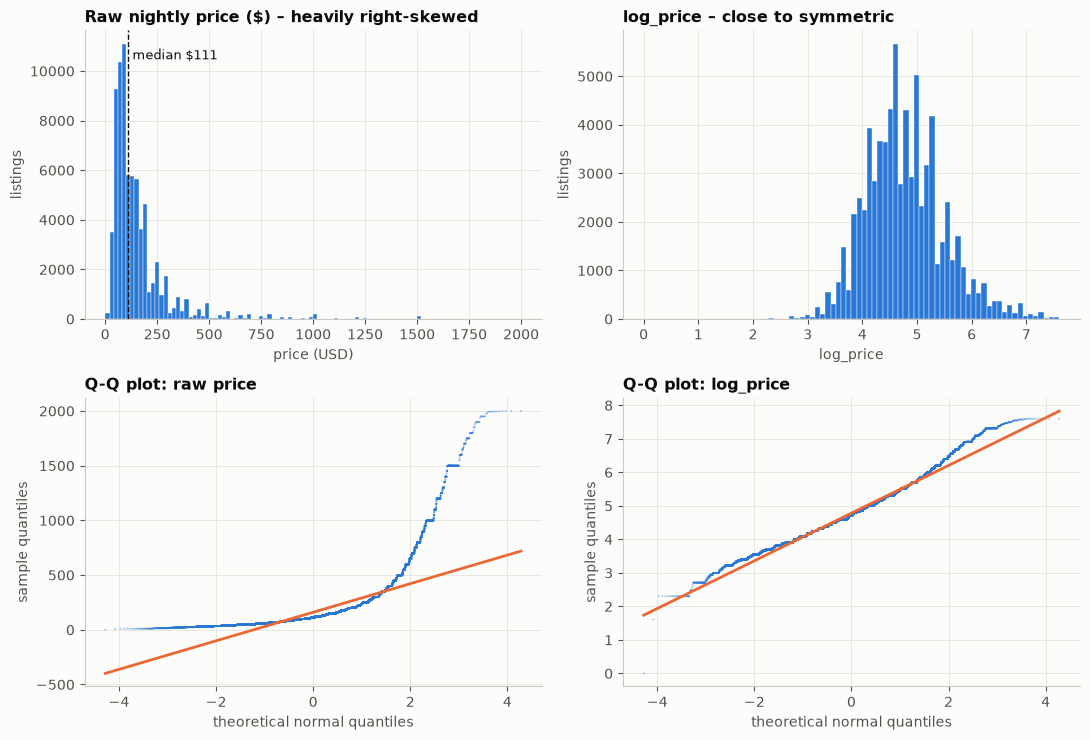

,skewness,excess kurtosis,mean,median,std
price,4.298,26.554,160.371,111.000,168.580
log_price,0.515,0.661,4.782,4.710,0.717


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
ax = axes[0, 0]
ax.hist(df["price"], bins=100, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.set_title("Raw nightly price ($) – heavily right-skewed"); ax.set_xlabel("price (USD)"); ax.set_ylabel("listings")
ax.axvline(df["price"].median(), color=INK, lw=1, ls="--"); ax.text(df["price"].median() + 20, ax.get_ylim()[1] * .9, f"median ${df['price'].median():.0f}", fontsize=9)
ax = axes[0, 1]
ax.hist(df["log_price"], bins=80, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.set_title("log_price – close to symmetric"); ax.set_xlabel("log_price"); ax.set_ylabel("listings")
for ax, col, ttl in [(axes[1, 0], "price", "Q-Q plot: raw price"), (axes[1, 1], "log_price", "Q-Q plot: log_price")]:
    (osm, osr), (slope, icpt, _) = stats.probplot(df[col], dist="norm")
    ax.scatter(osm, osr, s=2, color=BLUE, alpha=.4, edgecolors="none")
    ax.plot(osm, slope * osm + icpt, color=ORANGE, lw=2)
    ax.set_title(ttl); ax.set_xlabel("theoretical normal quantiles"); ax.set_ylabel("sample quantiles")
fig.tight_layout()
save(fig, "06_target_distribution")

shape = pd.DataFrame({c: {"skewness": df[c].skew(), "excess kurtosis": df[c].kurt(),
                          "mean": df[c].mean(), "median": df[c].median(), "std": df[c].std()}
                      for c in ["price", "log_price"]}).T
shape

In [14]:
# Where are the extremes of the target on the log scale?
q1, q3 = df["log_price"].quantile([.25, .75]); iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"IQR fences on log_price: [{lo:.2f}, {hi:.2f}]  =  [${np.exp(lo):,.0f}, ${np.exp(hi):,.0f}]")
print(f"Below lower fence: {(df['log_price'] < lo).sum()}   Above upper fence: {(df['log_price'] > hi).sum()}")
city_price = (df.groupby("city")["price"].describe(percentiles=[.5])
                .rename(columns={"50%": "median"})[["count", "mean", "median", "std", "min", "max"]]
                .sort_values("median", ascending=False))
city_price

IQR fences on log_price: [2.96, 6.57]  =  [$19, $717]
Below lower fence: 160   Above upper fence: 1372


,count,mean,median,std,min,max
city,,,,,,
SF,"6,434.000",227.373,165.000,204.736,10.000,"1,995.000"
Boston,"3,468.000",165.631,136.000,128.889,17.000,"1,400.000"
DC,"5,688.000",217.933,125.000,257.413,10.000,"1,999.000"
NYC,"32,349.000",143.025,105.000,130.635,1.000,"1,999.000"
LA,"22,453.000",155.388,100.000,180.451,10.000,"1,999.000"
Chicago,"3,719.000",132.476,99.000,124.838,10.000,"1,500.000"


**Observations & implications**
- Raw price has **skewness 4.30 and very heavy tails**: most listings cost $75–$185 (the IQR), and a long tail runs up to $1,999. After the log transform the skewness falls to **0.51** and the Q-Q plot is close to the normal line. The only deviation is in the tails, and the ceiling makes the upper tail flatten.
- **Why this matters:** Linear, Ridge and Lasso regression assume roughly constant error variance. A log target turns *multiplicative* price effects (e.g. "+1 bedroom ≈ +x% price") into *additive* ones and down-weights luxury outliers. Tree models (RF, XGBoost) do not require it, but they still benefit because the loss is no longer dominated by a few very expensive listings. **Decision:** model `log_price` and back-transform with `exp()` for the $ output. We also report MAE/RMSE in dollars.
- On the log scale the IQR fences are **$19 and $717**. They flag 160 listings below and 1,372 above (2.1% in total). Apart from the < $10 errors, these are genuine budget rooms and luxury homes, i.e. real market behaviour. **Decision:** do *not* trim the target beyond the invalid < $10 rows.
- **The city matters:** median prices are SF $165 > Boston $136 > DC $125 > NYC $105 > LA $100 > Chicago $99. `city` is a key feature.

## 7. Numeric features – distributions & outliers

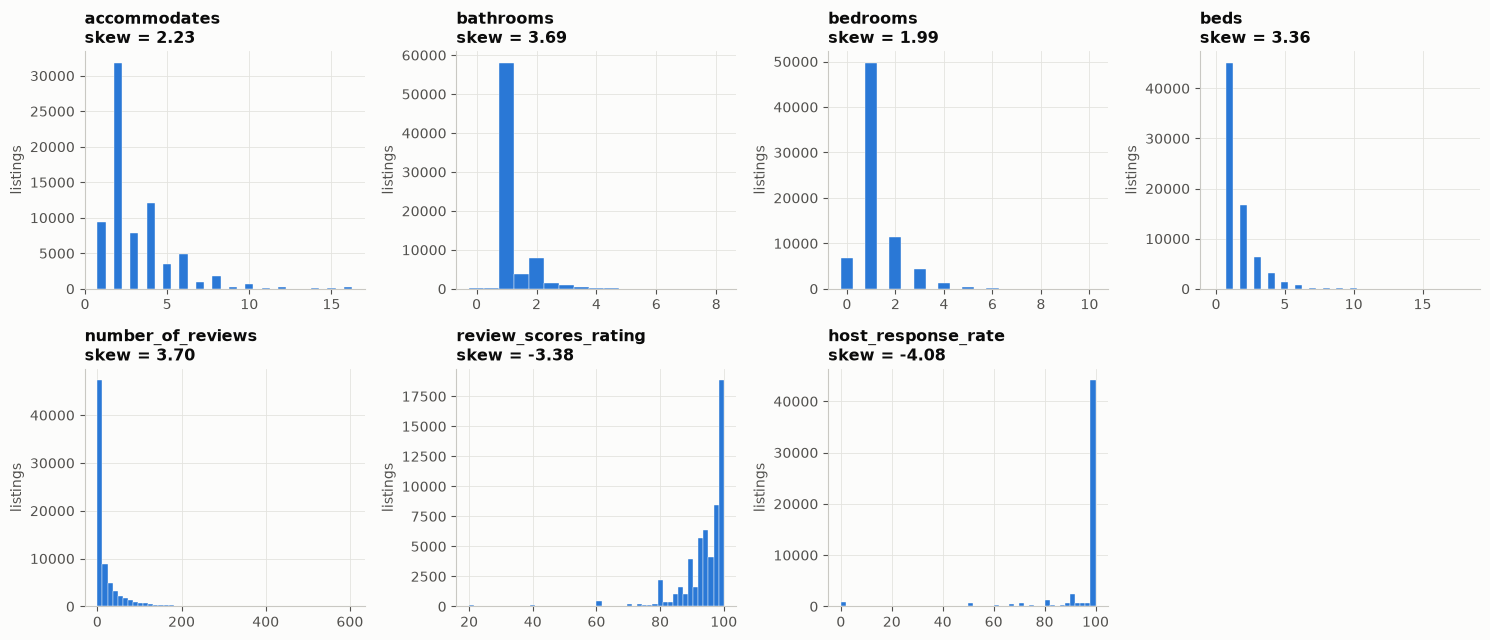

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, c in zip(axes.flat, NUM_COLS):
    s = df[c].dropna()
    discrete = c in ["accommodates", "bathrooms", "bedrooms", "beds"]
    bins = np.arange(s.min() - .25, s.max() + .75, .5) if discrete else 50
    ax.hist(s, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
    ax.set_title(f"{c}\nskew = {s.skew():.2f}"); ax.set_ylabel("listings")
axes.flat[-1].axis("off")
fig.tight_layout()
save(fig, "07_numeric_histograms")

In [16]:
def outlier_table(frame, cols):
    rows = []
    for c in cols:
        s = frame[c].dropna()
        q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
        z = np.abs(stats.zscore(s))
        rows.append({"feature": c, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "> 1.5·IQR (count)": int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()),
                     "> 3·IQR (count)": int(((s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)).sum()),
                     "|z| > 3 (count)": int((z > 3).sum()),
                     "99th pct": s.quantile(.99), "max": s.max()})
    return pd.DataFrame(rows).set_index("feature")
outlier_table(df, NUM_COLS)

,Q1,Q3,IQR,> 1.5·IQR (count),> 3·IQR (count),|z| > 3 (count),99th pct,max
feature,,,,,,,,
accommodates,2.000,4.000,2.000,3604,838,1539,12.000,16.000
bathrooms,1.000,1.000,0.000,15812,15812,2101,3.500,8.000
bedrooms,1.000,1.000,0.000,24236,24236,1861,4.000,10.000
beds,1.000,2.000,1.000,5686,1334,1334,6.000,18.000
number_of_reviews,1.000,23.000,22.000,8203,4145,1781,178.000,605.000
review_scores_rating,92.000,100.000,8.000,1719,814,1043,100.000,100.000
host_response_rate,100.000,100.000,0.000,12558,12558,1454,100.000,100.000


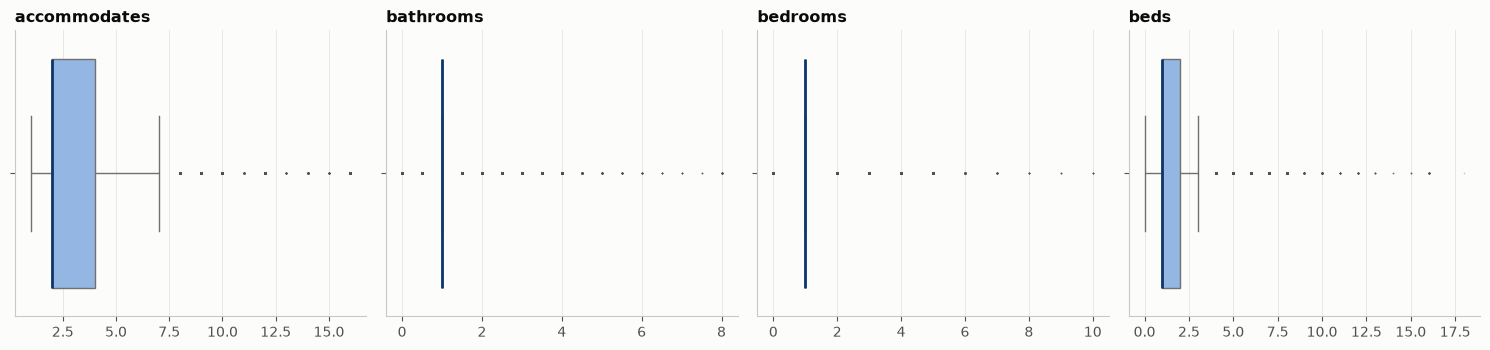

Largest capacity listings:


,accommodates,bedrooms,beds,bathrooms,property_type,room_type,price
306,16,2.000,3.000,2.000,Apartment,Entire home/apt,310.000
457,16,6.000,10.000,2.000,Townhouse,Entire home/apt,698.000
569,16,0.000,1.000,1.000,Loft,Private room,"1,250.000"
779,16,1.000,2.000,1.500,Apartment,Entire home/apt,375.000
1095,16,7.000,10.000,2.000,Apartment,Entire home/apt,450.000
1250,16,1.000,1.000,2.000,Other,Private room,384.000


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, c in zip(axes, ["accommodates", "bathrooms", "bedrooms", "beds"]):
    sns.boxplot(x=df[c], ax=ax, **BOX_KW)
    ax.set_title(c); ax.set_xlabel("")
fig.tight_layout()
save(fig, "07_numeric_boxplots")
print("Largest capacity listings:")
display(df.nlargest(6, "accommodates")[["accommodates", "bedrooms", "beds", "bathrooms", "property_type", "room_type", "price"]])

**Observations & implications**
- **The IQR rule is misleading for discrete, low-range counts.** For `bedrooms`, `bathrooms` and `host_response_rate` the IQR is **0** (Q1 = Q3). Every value other than the mode is then flagged as an "outlier": 24,236 bedroom rows (every studio and 2+ bedroom flat), 15,812 bathroom rows and 12,558 response-rate rows. We therefore judge outliers by **domain plausibility** (Section 5) and the 99th percentile, not by a blind IQR/z-score cut.
- The 99th percentiles (12 guests, 3.5 baths, 4 bedrooms, 6 beds) are far below the maxima (16, 8, 10, 18), so the extremes are rare. Most very large listings are genuine big houses (e.g. a 16-guest townhouse with 6 bedrooms and 10 beds). Some are **internally inconsistent**, e.g. a 16-guest *private room* with 0 bedrooms and 1 bed. **Decision:** keep the plausible ones, and **cap (winsorise) at the 99th/99.5th percentile** for the linear models only, since tree models are insensitive to extreme x-values. The ratio features (guests per bed) will expose the inconsistent rows.
- `number_of_reviews` (skew ≈ 3.7) needs a **`log1p` transform** for linear models. It is also a leakage suspect (Section 16).
- `review_scores_rating` is **left-skewed** (skew ≈ −3.4, bunched at 90–100). Its few very low scores are real guest opinions, so we keep them.
- `host_response_rate` is almost binary (100% vs. less). A `response_rate_100` flag may carry most of its signal.
- **Scaling:** the features are on very different ranges (counts 0–16, rating 20–100, lat/lon), so we apply **StandardScaler for Linear/Ridge/Lasso** only. Tree models need no scaling.

## 8. Categorical & boolean features

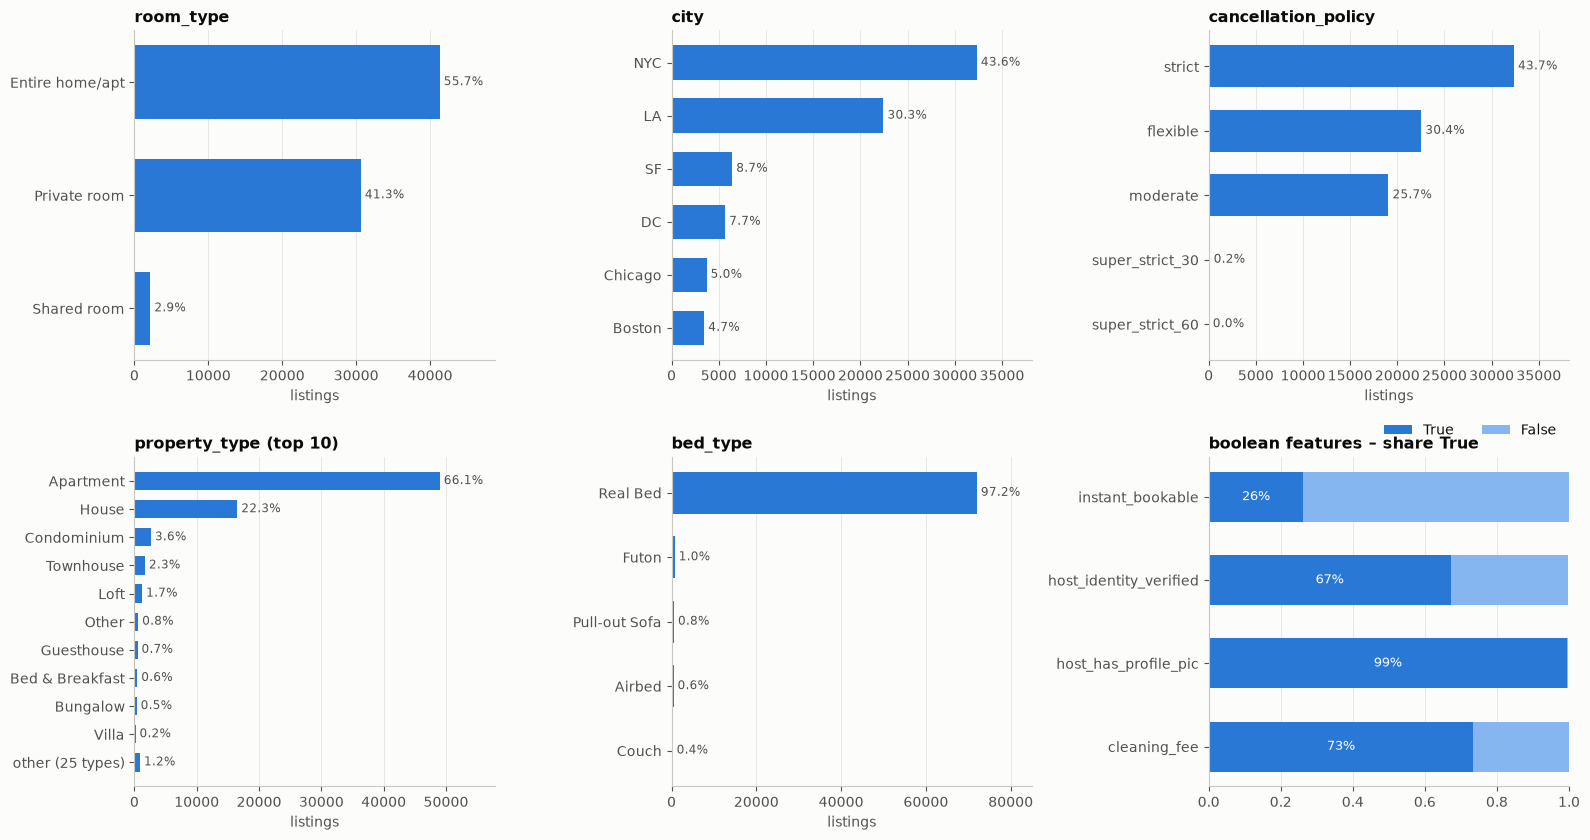

In [18]:
def bar_counts(ax, s, title, top=None):
    vc = s.value_counts(dropna=False)
    if top and len(vc) > top:
        vc = pd.concat([vc.iloc[:top], pd.Series({f"other ({len(vc) - top} types)": vc.iloc[top:].sum()})])
    vc.index = vc.index.map(lambda x: "Missing" if pd.isna(x) else str(x))
    ax.barh(vc.index[::-1], vc.values[::-1], color=BLUE, height=0.65)
    for y, v in enumerate(vc.values[::-1]):
        ax.text(v, y, f" {v / len(s):.1%}", va="center", fontsize=8.5, color=INK2)
    ax.set_title(title); ax.grid(axis="y", visible=False); ax.set_xlabel("listings")
    ax.set_xlim(0, vc.max() * 1.18)

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
bar_counts(axes[0, 0], df["room_type"], "room_type")
bar_counts(axes[0, 1], df["city"], "city")
bar_counts(axes[0, 2], df["cancellation_policy"], "cancellation_policy")
bar_counts(axes[1, 0], df["property_type"], "property_type (top 10)", top=10)
bar_counts(axes[1, 1], df["bed_type"], "bed_type")
bools = ["cleaning_fee", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
share = pd.DataFrame({c: df[c].value_counts(normalize=True, dropna=False) for c in bools}).T.reindex(columns=[True, False, np.nan]).fillna(0)
axes[1, 2].barh(share.index, share[True], color=BLUE, height=.6, label="True")
axes[1, 2].barh(share.index, share[False], left=share[True], color=BLUE_LIGHT, height=.6, label="False")
for y, v in enumerate(share[True]): axes[1, 2].text(v / 2, y, f"{v:.0%}", va="center", ha="center", color="white", fontsize=9)
axes[1, 2].set_title("boolean features – share True"); axes[1, 2].legend(loc="lower right", bbox_to_anchor=(1, 1.02), ncol=2)
axes[1, 2].set_xlim(0, 1); axes[1, 2].grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "08_categorical_counts")

In [19]:
pt = df["property_type"].value_counts()
print(f"property_type: {len(pt)} levels; {(pt < 100).sum()} levels have < 100 listings "
      f"(together {pt[pt < 100].sum()} rows = {pt[pt < 100].sum() / len(df):.1%})")
print(pt[pt < 100].to_string())

for c in ["neighbourhood", "zipcode"]:
    vc = df[c].value_counts()
    print(f"\n{c}: {len(vc)} levels | median listings per level = {vc.median():.0f} | "
          f"levels with < 10 listings = {(vc < 10).sum()} ({(vc < 10).mean():.0%} of levels) | "
          f"top 20 levels cover {vc.iloc[:20].sum() / vc.sum():.0%} of rows")
print("\nNeighbourhood names reused across cities:",
      (df.groupby("neighbourhood")["city"].nunique() > 1).sum())

property_type: 35 levels; 23 levels have < 100 listings (together 626 rows = 0.8%)
property_type
Camper/RV             94
Timeshare             77
Cabin                 72
In-law                71
Hostel                70
Boutique hotel        69
Boat                  65
Serviced apartment    21
Tent                  18
Castle                13
Vacation home         11
Yurt                   9
Hut                    8
Treehouse              7
Chalet                 6
Earth House            4
Tipi                   3
Train                  2
Cave                   2
Casa particular        1
Parking Space          1
Lighthouse             1
Island                 1

neighbourhood: 619 levels | median listings per level = 25 | levels with < 10 listings = 203 (33% of levels) | top 20 levels cover 36% of rows

zipcode: 769 levels | median listings per level = 25 | levels with < 10 listings = 251 (33% of levels) | top 20 levels cover 23% of rows

Neighbourhood names reused across cities: 19


**Observations & implications**
- **`room_type`**: Entire home/apt 55.7%, Private room 41.3%, **Shared room only 2.9%**. This is an important, clean, low-cardinality feature, so we use **one-hot encoding**.
- **`city`** is imbalanced: **NYC (43.6%) and LA (30.3%)** make up almost three-quarters of the data, and Boston and Chicago are ~5% each. A model could underfit the small cities, so we evaluate errors **per city** in modelling.
- **`property_type`** has 35 levels, but Apartment (66%) and House (22%) dominate. **23 levels have fewer than 100 listings** (0.8% of rows in total), including singletons such as Lighthouse, Island and Parking Space. **Decision:** group rare levels (< 100 rows, decided on the training set) into `"Other"` before one-hot encoding.
- **`bed_type`** is 97% "Real Bed", so it has near-zero variance. **Decision:** collapse it to a binary `is_real_bed` flag or drop it in feature selection.
- **`cancellation_policy`**: `super_strict_30` (112) and `super_strict_60` (17) are very rare. **Decision:** merge them into `strict`, then ordinal-encode.
- **`host_has_profile_pic`** is 99.7% True, so it has almost no information and is a drop candidate. `cleaning_fee` (73% True), `instant_bookable` (26%) and `host_identity_verified` (67%) have useful spread.
- **`neighbourhood`** has 619 levels. The median level has only 25 listings, and **203 levels (33%) have fewer than 10**. One-hot encoding would create a sparse, overfitting-prone matrix. **Decision:** **smoothed target encoding fitted inside CV folds on training data only** (to avoid leakage), or frequency encoding. **19 neighbourhood names appear in more than one city**, so we encode the combination `city + neighbourhood`.

## 9. Feature ↔ target relationships

,Pearson r,Spearman ρ,n
feature,,,
accommodates,0.568,0.589,74111
beds,0.442,0.481,73980
bedrooms,0.473,0.408,74020
bathrooms,0.355,0.283,73911
longitude,-0.048,-0.162,74111
review_scores_rating,0.091,0.085,57389
number_of_reviews,-0.032,-0.033,74111
latitude,-0.002,0.005,74111
host_response_rate,-0.007,-0.000,55812


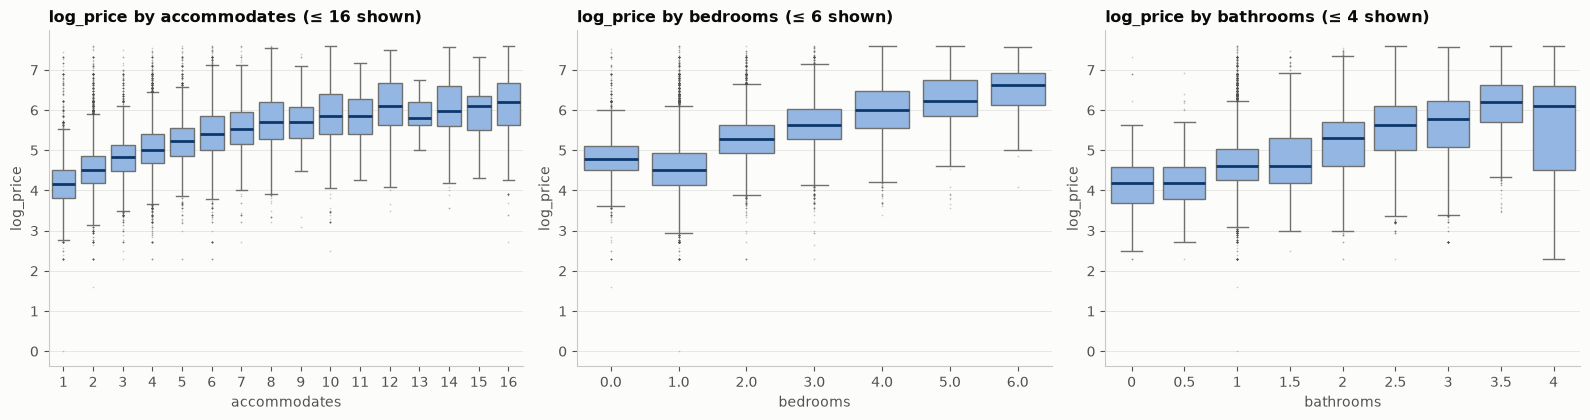

In [20]:
corr_rows = []
for c in NUM_COLS + ["latitude", "longitude"]:
    d = df[[c, "log_price"]].dropna()
    corr_rows.append({"feature": c, "Pearson r": d[c].corr(d["log_price"]),
                      "Spearman ρ": d[c].corr(d["log_price"], method="spearman"), "n": len(d)})
num_corr = pd.DataFrame(corr_rows).set_index("feature").sort_values("Spearman ρ", key=abs, ascending=False)
display(num_corr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, c, lim in zip(axes, ["accommodates", "bedrooms", "bathrooms"], [16, 6, 4]):
    d = df[df[c] <= lim]
    sns.boxplot(data=d, x=c, y="log_price", ax=ax, **BOX_KW)
    ax.set_title(f"log_price by {c} (≤ {lim} shown)")
    if c == "bathrooms": ax.set_xticklabels([f"{float(t.get_text()):g}" for t in ax.get_xticklabels()])
fig.tight_layout()
save(fig, "09_numeric_vs_target")

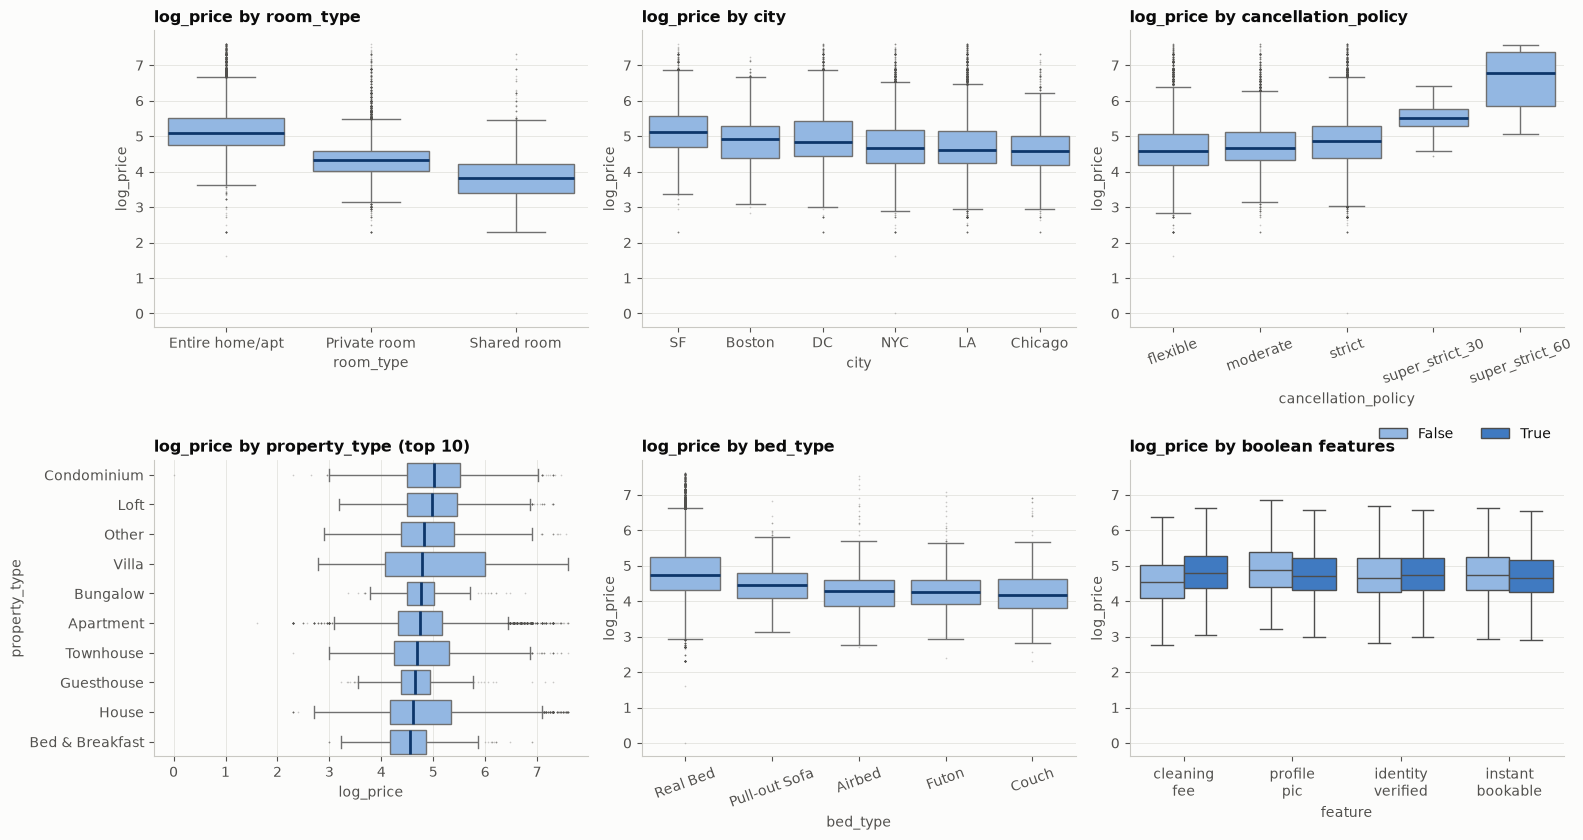

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
order = lambda c: df.groupby(c)["log_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="log_price", order=order("room_type"), ax=axes[0, 0], **BOX_KW)
sns.boxplot(data=df, x="city", y="log_price", order=order("city"), ax=axes[0, 1], **BOX_KW)
sns.boxplot(data=df, x="cancellation_policy", y="log_price",
            order=["flexible", "moderate", "strict", "super_strict_30", "super_strict_60"], ax=axes[0, 2], **BOX_KW)
top_pt = df["property_type"].value_counts().index[:10]
d = df[df["property_type"].isin(top_pt)]
sns.boxplot(data=d, y="property_type", x="log_price", order=d.groupby("property_type")["log_price"].median().sort_values(ascending=False).index,
            ax=axes[1, 0], **BOX_KW)
sns.boxplot(data=df, x="bed_type", y="log_price", order=order("bed_type"), ax=axes[1, 1], **BOX_KW)
b = df.melt(id_vars="log_price", value_vars=bools, var_name="feature", value_name="value").dropna()
sns.boxplot(data=b, x="feature", y="log_price", hue="value", palette={True: BLUE, False: BLUE_LIGHT},
            linewidth=1, fliersize=0, ax=axes[1, 2])
axes[1, 2].set_xticklabels(["cleaning\nfee", "profile\npic", "identity\nverified", "instant\nbookable"])
axes[1, 2].legend(title="", ncol=2, loc="lower right", bbox_to_anchor=(1, 1.02))
for ax, t in zip(axes.flat, ["room_type", "city", "cancellation_policy", "property_type (top 10)", "bed_type", "boolean features"]):
    ax.set_title(f"log_price by {t}")
for ax in [axes[0, 2], axes[1, 1]]: ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
save(fig, "09_categorical_vs_target")

In [22]:
# Effect size of every categorical/boolean feature on log_price:
# eta² = share of target variance explained by group means (one-way ANOVA); Kruskal-Wallis = non-parametric test
def eta_squared(cat, y):
    d = pd.DataFrame({"c": cat, "y": y}).dropna()
    g = d.groupby("c", observed=True)["y"].agg(["mean", "size"])
    ss_between = (g["size"] * (g["mean"] - d["y"].mean()) ** 2).sum()
    ss_total = ((d["y"] - d["y"].mean()) ** 2).sum()
    kw = stats.kruskal(*[grp.values for _, grp in d.groupby("c", observed=True)["y"]])
    return ss_between / ss_total, d["c"].nunique(), kw.pvalue

cat_cols = ["room_type", "city", "property_type", "bed_type", "cancellation_policy", "neighbourhood"] + bools
eff = pd.DataFrame([dict(zip(["eta²", "levels", "Kruskal-Wallis p"], eta_squared(df[c], df["log_price"])), feature=c)
                    for c in cat_cols]).set_index("feature").sort_values("eta²", ascending=False)
eff["levels"] = eff["levels"].astype(int)
eff

,eta²,levels,Kruskal-Wallis p
feature,,,
room_type,0.375,3,0.000
neighbourhood,0.253,619,0.000
city,0.041,6,0.000
cancellation_policy,0.020,5,0.000
property_type,0.017,35,0.000
cleaning_fee,0.012,2,0.000
bed_type,0.010,5,0.000
instant_bookable,0.002,2,0.000
host_identity_verified,0.001,2,0.000


**Observations & implications**
- **Size is the strongest numeric driver.** Spearman ρ with `log_price`: `accommodates` 0.59, `beds` 0.48, `bedrooms` 0.41, `bathrooms` 0.28. Price rises **monotonically but with diminishing returns** for very large units. This supports log/ratio features or tree models.
- **`room_type` is the single most powerful categorical** (η² = 0.375, i.e. it alone explains ~37% of the variance in `log_price`). Median prices: Entire home $160, Private room $75, Shared room $45. An entire home costs ~2.1× a private room.
- **Location matters:** `neighbourhood` explains η² = 0.25. Part of that is inflated by its 619 levels, but it confirms that **local area is a strong signal**, which justifies target encoding plus distance features. `city` alone explains only η² = 0.04, because most price variation is *within* cities.
- **`cancellation_policy`** (η² = 0.02) shows an upward trend: stricter policies go with higher prices (these tend to be professional or entire-home listings), consistent with treating it as ordinal.
- `cleaning_fee = True` listings are pricier (η² = 0.012), which likely reflects bigger, entire-home properties.
- **Weak or no signal:** `number_of_reviews` (ρ = −0.03), `review_scores_rating` (0.09), `host_response_rate` (0.00), `host_has_profile_pic`, `host_identity_verified` and `instant_bookable` (η² ≤ 0.002). They are candidates for removal in feature selection.
- All Kruskal-Wallis p-values are tiny, but with 74k rows **almost any difference is "significant"**. We therefore rank features by **effect size (η², ρ)**, not by p-value.

## 10. Multicollinearity & interactions

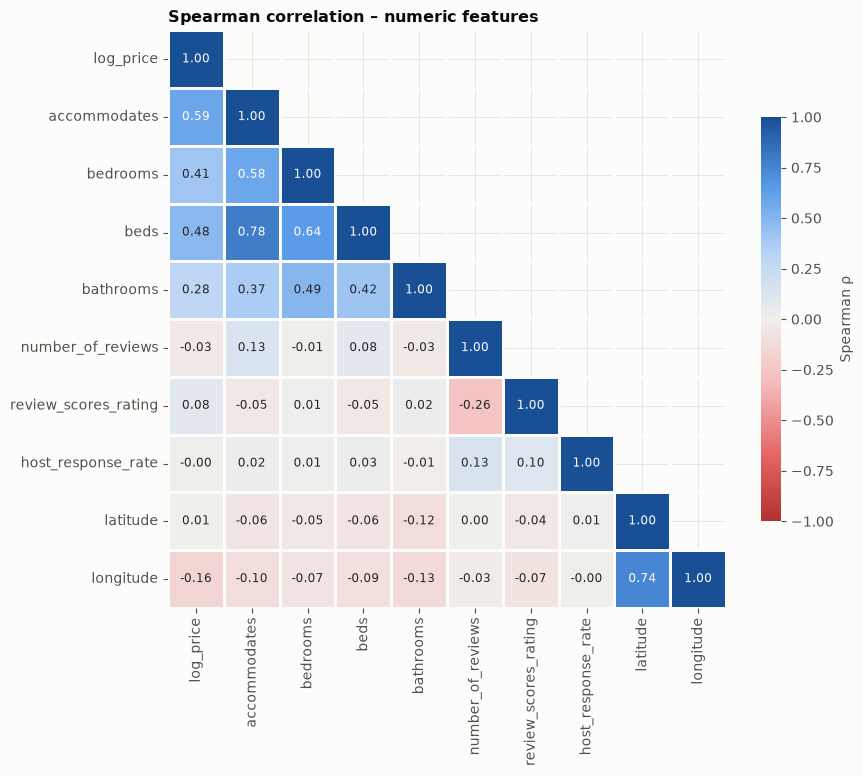

,VIF
accommodates,3.273
bedrooms,2.531
beds,3.312
bathrooms,1.594


In [23]:
corr_cols = ["log_price", "accommodates", "bedrooms", "beds", "bathrooms", "number_of_reviews",
             "review_scores_rating", "host_response_rate", "latitude", "longitude"]
sp = df[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(sp, mask=np.triu(np.ones_like(sp, dtype=bool), 1), cmap=DIVERGING, vmin=-1, vmax=1, annot=True,
            fmt=".2f", annot_kws={"size": 8.5}, linewidths=2, linecolor=SURFACE, cbar_kws={"shrink": .7, "label": "Spearman ρ"}, ax=ax)
ax.set_title("Spearman correlation – numeric features")
save(fig, "10_correlation_heatmap")

size_cols = ["accommodates", "bedrooms", "beds", "bathrooms"]
X = df[size_cols].dropna()
vif = pd.Series({c: 1 / (1 - LinearRegression().fit(X.drop(columns=c), X[c]).score(X.drop(columns=c), X[c]))
                 for c in size_cols}, name="VIF")
vif.to_frame()

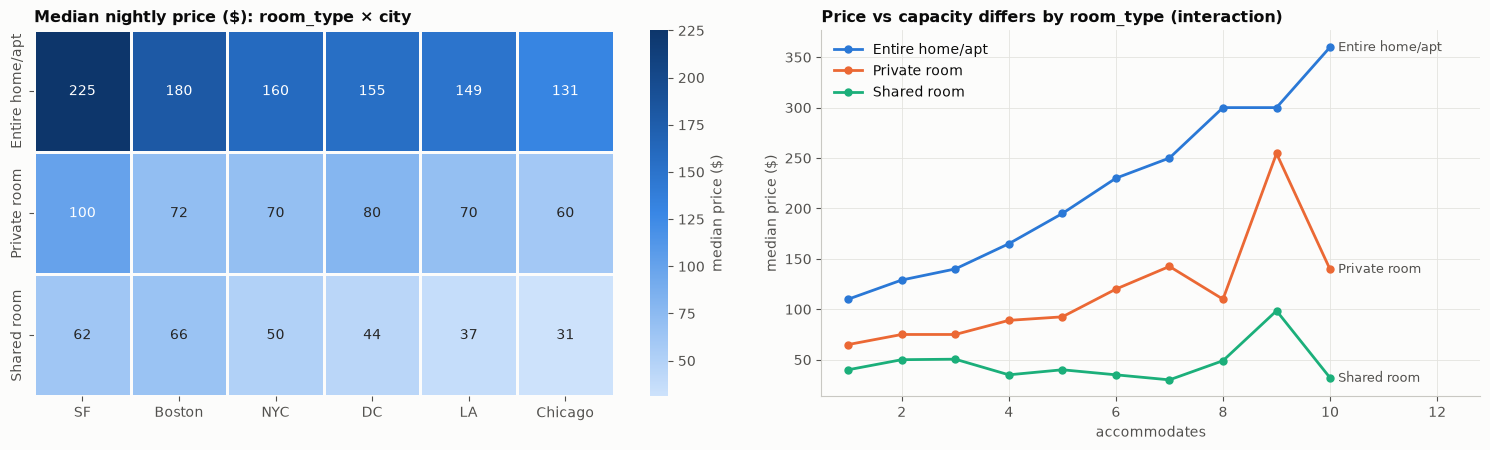

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
pivot = df.pivot_table(index="room_type", columns="city", values="price", aggfunc="median")
pivot = pivot[pivot.loc["Entire home/apt"].sort_values(ascending=False).index]
sns.heatmap(pivot, annot=True, fmt=".0f", cmap=SEQ_BLUE, linewidths=2, linecolor=SURFACE,
            cbar_kws={"label": "median price ($)"}, ax=axes[0])
axes[0].set_title("Median nightly price ($): room_type × city"); axes[0].set_xlabel(""); axes[0].set_ylabel("")

ax = axes[1]
g = df[df["accommodates"] <= 10].groupby(["room_type", "accommodates"])["price"].median().reset_index()
for rt, color in ROOM_COLORS.items():
    s = g[g["room_type"] == rt]
    ax.plot(s["accommodates"], s["price"], color=color, marker="o", ms=5, label=rt)
    ax.text(s["accommodates"].iloc[-1] + .15, s["price"].iloc[-1], rt, color=INK2, fontsize=9, va="center")
ax.set_xlabel("accommodates"); ax.set_ylabel("median price ($)"); ax.set_xlim(.5, 12.8)
ax.set_title("Price vs capacity differs by room_type (interaction)")
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "10_interactions")

**Observations & implications**
- **The size features are correlated** with one another: `accommodates`–`beds` ρ = 0.78, `bedrooms`–`beds` 0.64, `accommodates`–`bedrooms` 0.58. The VIFs are **1.6–3.3**, which is *moderate* multicollinearity (below the common threshold of 5–10). It will make individual Linear Regression coefficients less stable (hard to say "the effect of one extra bed"), but it will not hurt prediction much. **Decision:** use **Ridge/Lasso** (as planned) and ratio features (`beds_per_bedroom`, `guests_per_bedroom`) to separate the effects.
- `latitude` and `longitude` correlate with each other (ρ = 0.74) only because the six cities sit at distinct coordinates. Their *raw* correlation with price is ~0, because location acts **within** cities, which linear models cannot capture from raw lat/lon. **Decision:** engineer a `distance_to_centre` feature (Section 11).
- **Interaction:** a private room's price barely rises with capacity, while an entire home's price climbs steeply. The room_type × city table also shows that the city premium differs by room type. **Tree ensembles capture such interactions automatically**, which is one reason we expect RF/XGBoost to beat linear models.

## 11. Geospatial analysis

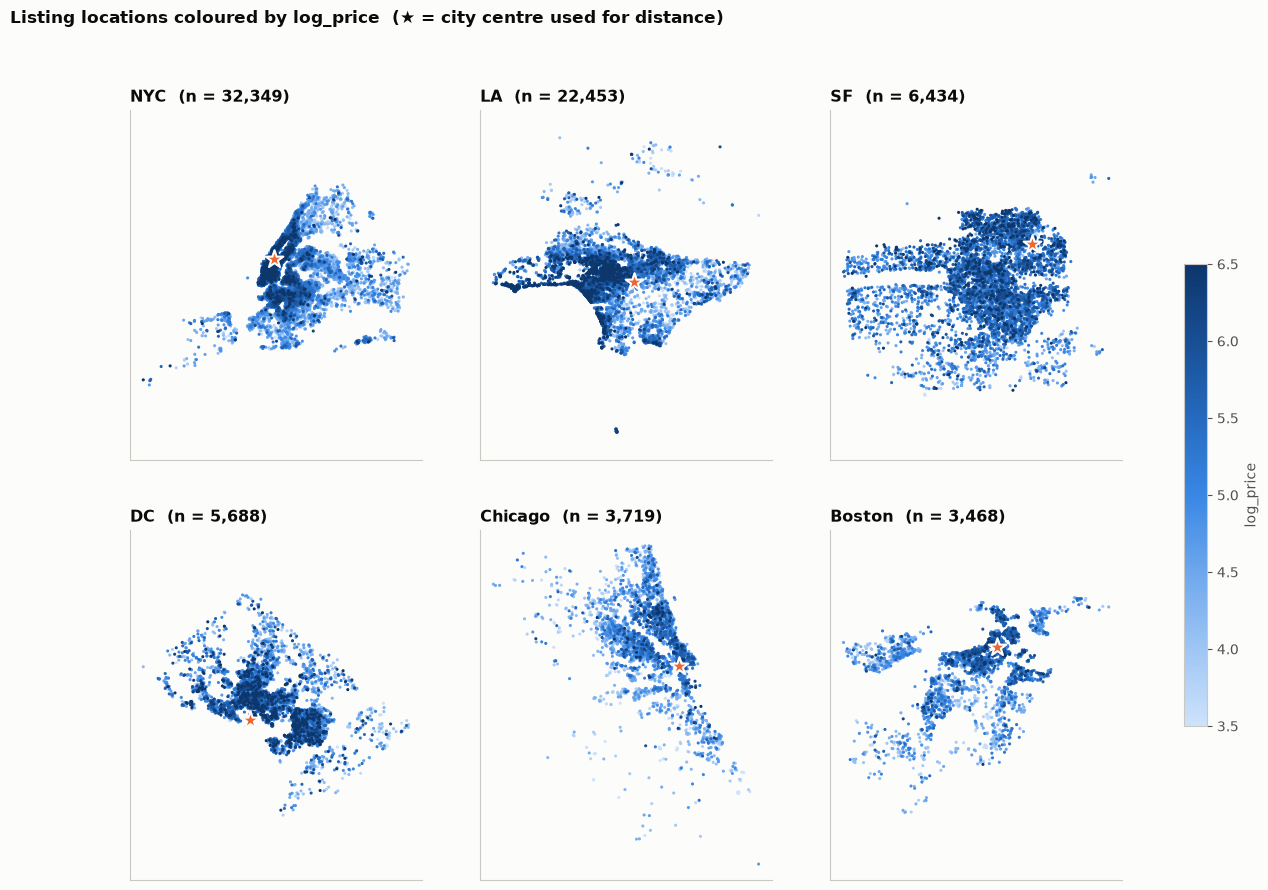

In [25]:
CENTRES = {"NYC": (40.7580, -73.9855),      # Times Square
           "LA": (34.0522, -118.2437),      # Downtown LA
           "SF": (37.7880, -122.4075),      # Union Square
           "DC": (38.8977, -77.0365),       # White House
           "Chicago": (41.8837, -87.6325),  # The Loop
           "Boston": (42.3551, -71.0656)}   # Boston Common

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

centre = df["city"].map(CENTRES)
df["dist_centre_km"] = haversine_km(df["latitude"], df["longitude"],
                                    centre.str[0].astype(float), centre.str[1].astype(float))

cities = df["city"].value_counts().index
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, c in zip(axes.flat, cities):
    d = df[df["city"] == c].sort_values("log_price")
    sc = ax.scatter(d["longitude"], d["latitude"], c=d["log_price"], cmap=SEQ_BLUE, s=1.5, vmin=3.5, vmax=6.5, rasterized=True)
    ax.scatter(*CENTRES[c][::-1], marker="*", s=180, color=ORANGE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_title(f"{c}  (n = {len(d):,})"); ax.set_aspect("equal", adjustable="datalim"); ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=.6, label="log_price")
fig.suptitle("Listing locations coloured by log_price  (★ = city centre used for distance)", x=.05, ha="left", fontweight="bold")
save(fig, "11_geo_maps")

,listings,median distance km,max distance km,"Spearman ρ (distance, log_price)","Spearman ρ (latitude, log_price)"
city,,,,,
Boston,"3,468.000",2.993,14.346,-0.494,0.266
NYC,"32,349.000",6.190,35.898,-0.457,0.133
Chicago,"3,719.000",6.142,26.294,-0.320,0.018
DC,"5,688.000",3.312,10.796,-0.249,-0.182
SF,"6,434.000",3.533,11.319,-0.170,0.194
LA,"22,453.000",15.414,82.310,0.056,-0.041


Pooled Spearman ρ, distance vs log_price: -0.272 (vs raw latitude 0.005)


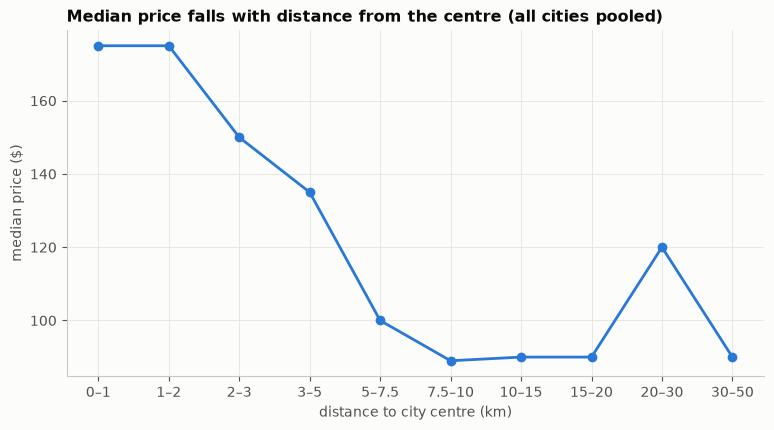

In [26]:
geo = df.groupby("city").apply(lambda d: pd.Series({
    "listings": len(d),
    "median distance km": d["dist_centre_km"].median(),
    "max distance km": d["dist_centre_km"].max(),
    "Spearman ρ (distance, log_price)": d["dist_centre_km"].corr(d["log_price"], method="spearman"),
    "Spearman ρ (latitude, log_price)": d["latitude"].corr(d["log_price"], method="spearman")}))
display(geo.sort_values("Spearman ρ (distance, log_price)"))
print(f"Pooled Spearman ρ, distance vs log_price: {df['dist_centre_km'].corr(df['log_price'], method='spearman'):.3f} "
      f"(vs raw latitude {df['latitude'].corr(df['log_price'], method='spearman'):.3f})")

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = [0, 1, 2, 3, 5, 7.5, 10, 15, 20, 30, 50]
df["dist_bin"] = pd.cut(df["dist_centre_km"], bins)
g = df.groupby("dist_bin", observed=True)["price"].median()
ax.plot(range(len(g)), g.values, color=BLUE, marker="o", ms=6)
ax.set_xticks(range(len(g))); ax.set_xticklabels([f"{i.left:g}–{i.right:g}" for i in g.index], rotation=0)
ax.set_xlabel("distance to city centre (km)"); ax.set_ylabel("median price ($)")
ax.set_title("Median price falls with distance from the centre (all cities pooled)")
save(fig, "11_distance_vs_price")
df = df.drop(columns="dist_bin")

**Observations & implications**
- The maps show clear **price hot-spots**: Manhattan and parts of Brooklyn (NYC), the coast and Hollywood Hills (LA), downtown and north-east SF, and central DC and Boston.
- Raw `latitude` has ρ = 0.005 with price across the pooled data, but **distance to the city centre has ρ = −0.27**. Within cities the effect is strong in **5 of 6 cities**: Boston −0.49, NYC −0.46, Chicago −0.32, DC −0.25, SF −0.17. The pooled median price falls steadily as distance grows. **Decision:** engineer `dist_centre_km` in Stage 4. It should help the linear models most.
- **LA is the exception (ρ = +0.06).** LA is polycentric (Santa Monica/Venice beaches, Hollywood Hills, Beverly Hills, downtown) and very spread out (median distance 15 km, max 82 km), so no single centre explains price. **Decision:** keep raw lat/lon for the tree models, which can learn several hot-spots, and consider distance-to-nearest-hot-spot or lat/lon clusters.
- No coordinates fall outside plausible metro regions (the maximum distances are metro-area scale), so **no geographic errors** need removal.

## 12. Amenities – parsing the text-list column

In [27]:
def parse_amenities(s):
    items = [a.strip().strip('"').strip() for a in str(s).strip("{}").split(",")]
    return [a for a in items if a]

df["amenity_list"] = df["amenities"].map(parse_amenities)
df["amenity_count"] = df["amenity_list"].str.len()
junk = lambda a: a.startswith("translation missing")

mlb = MultiLabelBinarizer()
A = pd.DataFrame(mlb.fit_transform(df["amenity_list"]), columns=mlb.classes_, index=df.index)
freq = A.mean().sort_values(ascending=False)
print(f"Distinct amenity tokens: {A.shape[1]}  |  junk 'translation missing' tokens: {sum(map(junk, A.columns))} "
      f"(present in {A[[c for c in A if junk(c)]].any(axis=1).mean():.1%} of listings)")
print(f"Listings with 0 amenities: {(df['amenity_count'] == 0).sum()}")
print(f"Tokens present in < 1% of listings: {(freq < .01).sum()}")
print("Overlapping tokens: 'Internet' & 'Wireless Internet' co-occur in "
      f"{(A['Internet'] & A['Wireless Internet']).mean():.1%} of listings; 'Elevator' vs 'Elevator in building' "
      f"both present {(A['Elevator'] & A['Elevator in building']).sum()} times")
print(f"Spearman ρ(amenity_count, log_price) = {df['amenity_count'].corr(df['log_price'], method='spearman'):.3f}")

Distinct amenity tokens: 130  |  junk 'translation missing' tokens: 2 (present in 36.8% of listings)
Listings with 0 amenities: 586
Tokens present in < 1% of listings: 60
Overlapping tokens: 'Internet' & 'Wireless Internet' co-occur in 59.8% of listings; 'Elevator' vs 'Elevator in building' both present 0 times
Spearman ρ(amenity_count, log_price) = 0.208


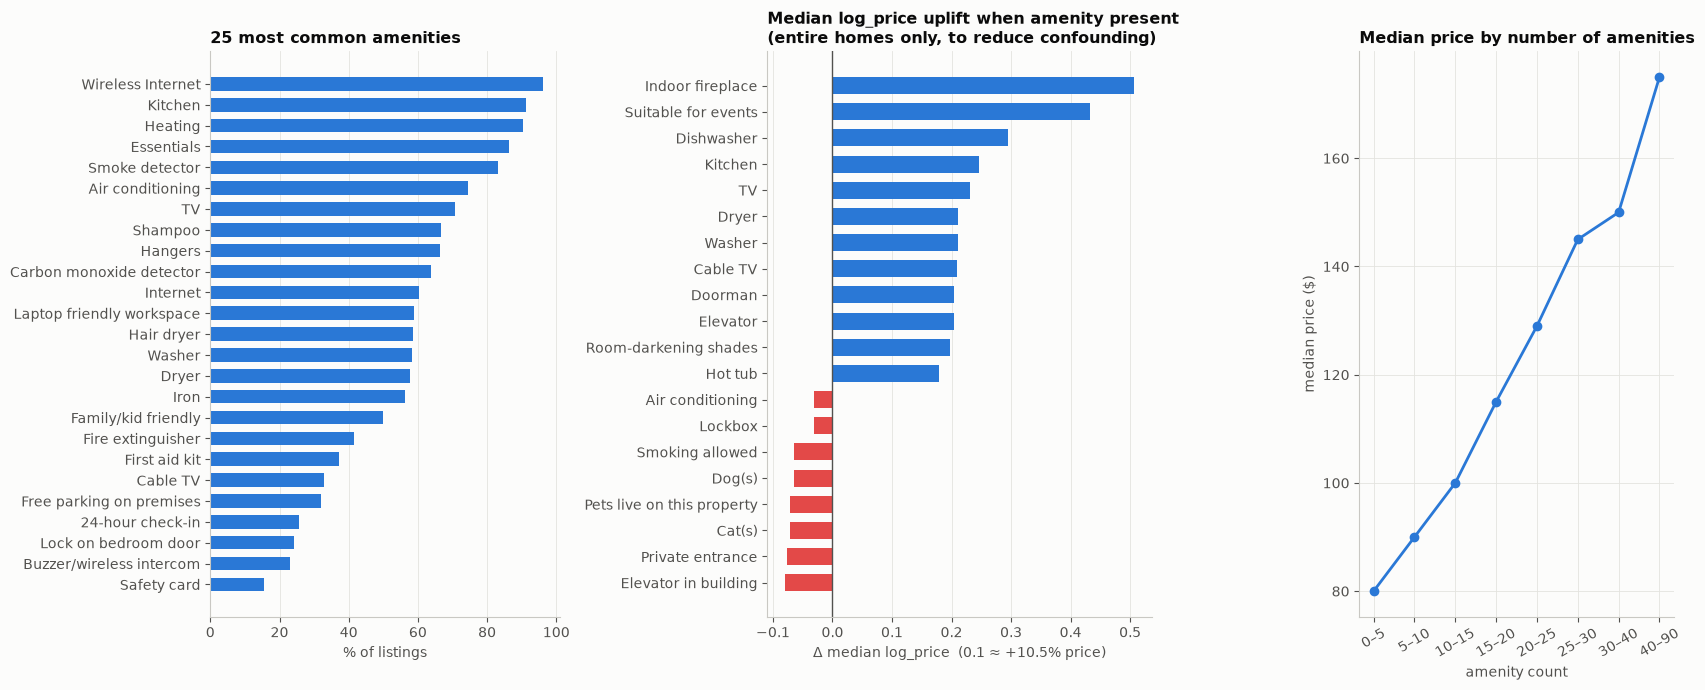

,prevalence,uplift (all),uplift (entire homes)
amenity,,,
Indoor fireplace,0.125,0.319,0.507
Suitable for events,0.058,0.310,0.432
Dishwasher,0.031,0.375,0.295
Kitchen,0.911,0.282,0.246
TV,0.706,0.409,0.231
Washer,0.582,0.223,0.211
Dryer,0.576,0.223,0.211
Cable TV,0.327,0.399,0.210
Doorman,0.059,0.415,0.204


In [28]:
real = [c for c in A.columns if not junk(c)]
ent = df["room_type"] == "Entire home/apt"
uplift_rows = []
for a in [c for c in real if freq[c] >= .02]:
    has = A[a] == 1
    uplift_rows.append({"amenity": a, "prevalence": freq[a],
                        "uplift (all)": df.loc[has, "log_price"].median() - df.loc[~has, "log_price"].median(),
                        "uplift (entire homes)": df.loc[has & ent, "log_price"].median() - df.loc[~has & ent, "log_price"].median()})
uplift = pd.DataFrame(uplift_rows).set_index("amenity").sort_values("uplift (entire homes)")

fig, axes = plt.subplots(1, 3, figsize=(17, 7), gridspec_kw={"width_ratios": [1, 1.1, .9]})
top = freq[real].sort_values(ascending=False).iloc[:25]
axes[0].barh(top.index[::-1], top.values[::-1] * 100, color=BLUE, height=.65)
axes[0].set_title("25 most common amenities"); axes[0].set_xlabel("% of listings"); axes[0].grid(axis="y", visible=False)

sel = pd.concat([uplift.head(8), uplift.tail(12)])
colors = [RED if v < 0 else BLUE for v in sel["uplift (entire homes)"]]
axes[1].barh(sel.index, sel["uplift (entire homes)"], color=colors, height=.65)
axes[1].axvline(0, color=INK2, lw=1)
axes[1].set_title("Median log_price uplift when amenity present\n(entire homes only, to reduce confounding)")
axes[1].set_xlabel("Δ median log_price  (0.1 ≈ +10.5% price)"); axes[1].grid(axis="y", visible=False)

g = df.groupby(pd.cut(df["amenity_count"], [0, 5, 10, 15, 20, 25, 30, 40, 90]), observed=True)["price"].median()
axes[2].plot(range(len(g)), g.values, color=BLUE, marker="o", ms=6)
axes[2].set_xticks(range(len(g))); axes[2].set_xticklabels([f"{i.left}–{i.right}" for i in g.index], rotation=30)
axes[2].set_title("Median price by number of amenities"); axes[2].set_xlabel("amenity count"); axes[2].set_ylabel("median price ($)")
fig.tight_layout()
save(fig, "12_amenities")
uplift.sort_values("uplift (entire homes)", ascending=False).head(10)

**Observations & implications**
- The `amenities` string parses into **130 distinct tokens**, and on average a listing lists **~17.6 amenities**. There are **2 junk tokens** (`translation missing: en.hosting_amenity_49/50`) in **36.8% of listings**; they carry no meaning. **Decision:** remove them. **60 tokens appear in < 1% of listings.** **Decision:** one-hot encode only amenities with ≥ 1–2% prevalence, since rare ones add noise and dimensions.
- There are **synonym tokens**:
  - `Elevator` (10,820 listings) and `Elevator in building` (6,417) **never co-occur**, which suggests the same amenity was renamed between data collections. They even show opposite price effects, so they must be merged.
  - `Internet` and `Wireless Internet` co-occur in 59.8% of listings (heavily overlapping).
  - **Decision:** merge synonyms before encoding.
- **Amenity count is positively related to price** (ρ = 0.21, a rising curve). **Decision:** add `amenity_count` as a feature.
- Within entire homes (to reduce confounding with room type), the largest **price premiums** are Indoor fireplace (+0.51 in log units ≈ +66%), Suitable for events, Dishwasher, Kitchen, TV, Washer/Dryer, Cable TV, Doorman and Elevator. The **negative** associations are Private entrance, Pets live on this property, Cat(s)/Dog(s), Smoking allowed and Lockbox, which signal budget or informal accommodation. These are *associations*, not causal effects.
- Very common amenities (Wifi 96%, Kitchen 91%, Heating 91%, Essentials 86%) have **low variance**. Their *absence* can still be informative: an entire home without a kitchen is cheaper. Feature selection will decide whether to keep them.

## 13. Dates – host tenure & review recency

Latest date in the data (used as snapshot date): 2017-10-05
host_since   : 2008-03-03  →  2017-10-04
first_review : 2008-11-17  →  2017-10-05
last_review  : 2009-01-21  →  2017-10-05


,Spearman ρ with log_price,median,missing %
host_tenure_yrs,0.094,3.020,0.254
listing_age_yrs,0.085,1.363,21.406
days_since_last_review,-0.014,160.000,21.356


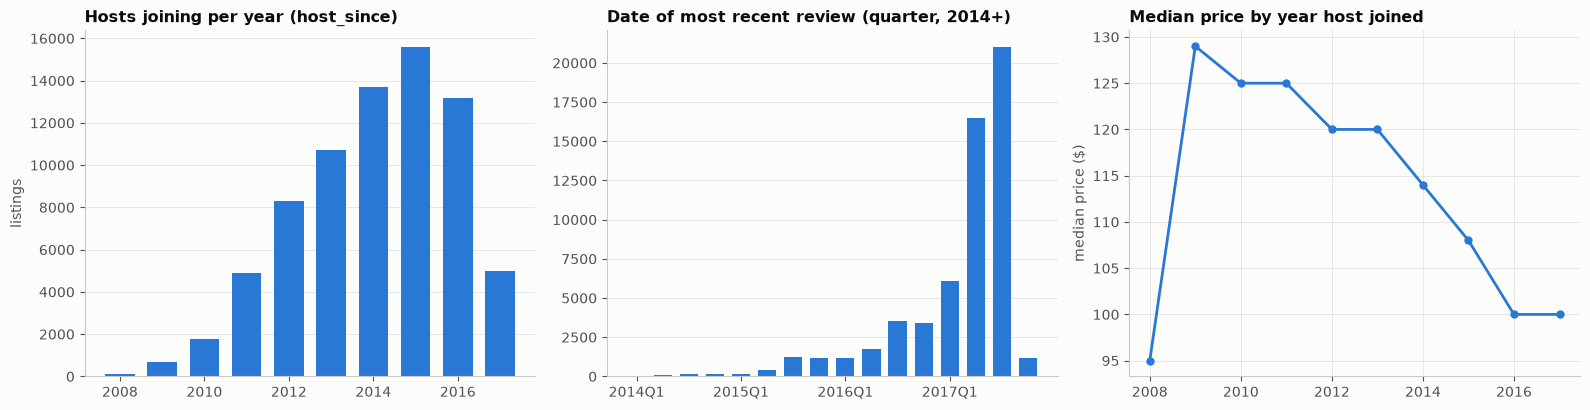

In [29]:
SNAPSHOT = df[["first_review", "last_review", "host_since"]].max().max()
print(f"Latest date in the data (used as snapshot date): {SNAPSHOT.date()}")
for c in ["host_since", "first_review", "last_review"]:
    print(f"{c:13s}: {df[c].min().date()}  →  {df[c].max().date()}")

df["host_tenure_yrs"] = (SNAPSHOT - df["host_since"]).dt.days / 365.25
df["days_since_last_review"] = (SNAPSHOT - df["last_review"]).dt.days
df["listing_age_yrs"] = (SNAPSHOT - df["first_review"]).dt.days / 365.25
date_corr = pd.DataFrame({c: {"Spearman ρ with log_price": df[c].corr(df["log_price"], method="spearman"),
                              "median": df[c].median(), "missing %": df[c].isna().mean() * 100}
                          for c in ["host_tenure_yrs", "listing_age_yrs", "days_since_last_review"]}).T
display(date_corr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
yr = df["host_since"].dt.year.value_counts().sort_index()
axes[0].bar(yr.index.astype(int), yr.values, color=BLUE, width=.7)
axes[0].set_title("Hosts joining per year (host_since)"); axes[0].set_ylabel("listings"); axes[0].grid(axis="x", visible=False)
ly = df["last_review"].dt.to_period("Q").value_counts().sort_index()
ly = ly[ly.index >= pd.Period("2014Q1")]
axes[1].bar(range(len(ly)), ly.values, color=BLUE, width=.7)
axes[1].set_xticks(range(0, len(ly), 4)); axes[1].set_xticklabels([str(p) for p in ly.index[::4]])
axes[1].set_title("Date of most recent review (quarter, 2014+)"); axes[1].grid(axis="x", visible=False)
g = df.groupby(df["host_since"].dt.year)["price"].median()
axes[2].plot(g.index.astype(int), g.values, color=BLUE, marker="o", ms=5)
axes[2].set_title("Median price by year host joined"); axes[2].set_ylabel("median price ($)")
fig.tight_layout()
save(fig, "13_dates")

**Observations & implications**
- The data is a **snapshot ending 5 Oct 2017**. Host sign-ups grew rapidly between 2012 and 2016, and most last reviews fall in 2017, so the majority of listings are active.
- Raw dates cannot be fed to models. **Decision:** convert them to numeric durations measured from the snapshot date: `host_tenure_yrs`, `listing_age_yrs` and `days_since_last_review`. For never-reviewed listings, the review-based durations are **not applicable**, so we use the `has_reviews` flag plus imputation.
- All three durations have **weak correlations with price**: `host_tenure_yrs` ρ = 0.09, `listing_age_yrs` 0.09, `days_since_last_review` −0.01. Longer-tenured hosts charge only slightly more. These are secondary features.
- `first_review`, `last_review` and `days_since_last_review` describe a listing's **booking history**, which does not exist for a brand-new listing. They are leakage-sensitive for our "new host" use case (Section 16). `host_since` *is* known at prediction time (the host knows when they joined).

## 14. Free-text columns – `name`, `description`, `thumbnail_url`

In [30]:
txt = pd.DataFrame({
    "name_len": raw["name"].str.len(),
    "description_len": raw["description"].str.len(),
    "description_words": raw["description"].str.split().str.len(),
    "has_thumbnail": raw["thumbnail_url"].notna().astype(int),
    "log_price": df["log_price"]})
display(txt.describe().T[["mean", "50%", "max"]])
display(txt.corr(method="spearman")["log_price"].drop("log_price").to_frame("Spearman ρ with log_price"))
kw = {k: raw["name"].str.contains(k, case=False, na=False) for k in ["luxury", "penthouse", "studio", "room", "cozy"]}
display(pd.DataFrame({k: {"listings": v.sum(), "median $ with": df.loc[v, "price"].median(),
                          "median $ without": df.loc[~v, "price"].median()} for k, v in kw.items()}).T)

,mean,50%,max
name_len,34.848,34.000,179.000
description_len,762.682,"1,000.000","1,000.000"
description_words,130.423,160.000,219.000
has_thumbnail,0.889,1.000,1.000
log_price,4.782,4.710,7.600


,Spearman ρ with log_price
name_len,0.062
description_len,0.067
description_words,-0.005
has_thumbnail,-0.118


,listings,median $ with,median $ without
luxury,"2,676.000",180.000,110.000
penthouse,712.000,209.500,110.000
studio,"5,518.000",120.000,110.000
room,"23,911.000",80.000,130.000
cozy,"6,393.000",85.000,119.000


**Observations & implications**
- The text lengths correlate only weakly with price (ρ ≈ 0.06). `description` is **truncated at 1,000 characters** in the source (the median length is exactly 1,000), so its length is not even a reliable measure.
- Listings *without* a thumbnail are somewhat pricier (ρ = −0.12). This is most likely a scraping artefact, and it is meaningless for a new host, who always uploads photos.
- So **dropping `id`, `name`, `description` and `thumbnail_url`** (as stated in our proposal) loses little structured information.
- Title keywords do separate prices ("luxury" and "penthouse" are pricier; "room" and "cozy" are cheaper), but those keywords mostly restate room type and size, which are already features. NLP features are a possible **future improvement**, not part of our core pipeline.
- The description is also the column where a host might write the price ("only $80/night"). Dropping free text also removes that potential target leak.

## 15. Target balance across groups (the regression equivalent of class imbalance)

price_band,Q1 cheapest,Q2,Q3,Q4,Q5 priciest
room_type,,,,,
Entire home/apt,2%,11%,24%,31%,32%
Private room,41%,31%,17%,7%,3%
Shared room,75%,13%,7%,3%,2%


price_band,Q1 cheapest,Q2,Q3,Q4,Q5 priciest
city,,,,,
Boston,16%,15%,19%,27%,23%
Chicago,27%,20%,21%,17%,14%
DC,13%,19%,22%,19%,27%
LA,23%,22%,21%,17%,17%
NYC,23%,20%,20%,21%,16%
SF,5%,13%,20%,26%,36%


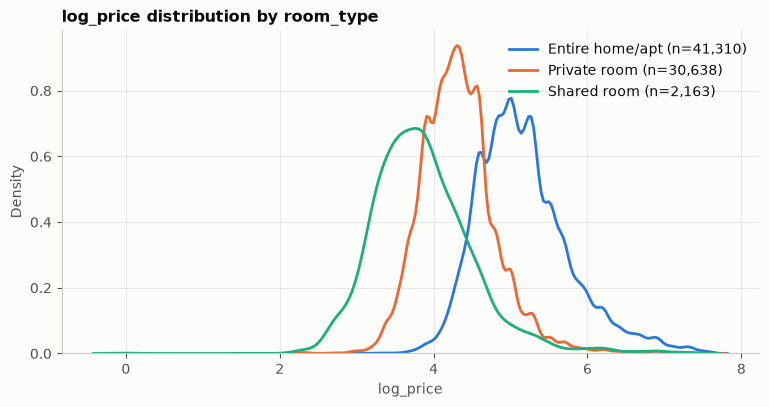

In [31]:
df["price_band"] = pd.qcut(df["log_price"], 5, labels=["Q1 cheapest", "Q2", "Q3", "Q4", "Q5 priciest"])
display(pd.crosstab(df["room_type"], df["price_band"], normalize="index").style.format("{:.0%}").background_gradient(cmap=SEQ_BLUE, axis=None))
display(pd.crosstab(df["city"], df["price_band"], normalize="index").style.format("{:.0%}").background_gradient(cmap=SEQ_BLUE, axis=None))

fig, ax = plt.subplots(figsize=(9, 4.2))
for rt, color in ROOM_COLORS.items():
    sns.kdeplot(df.loc[df["room_type"] == rt, "log_price"], ax=ax, color=color, lw=2, label=f"{rt} (n={(df['room_type'] == rt).sum():,})")
ax.set_title("log_price distribution by room_type"); ax.set_xlabel("log_price"); ax.legend(loc="upper right")
save(fig, "15_target_by_room_type")
df = df.drop(columns="price_band")

**Observations & implications**
- As a regression problem there are no classes. However, the target is **unevenly represented across groups**:
  - **75% of shared rooms** fall in the cheapest price quintile, and 72% of private rooms fall in the two cheapest.
  - 63% of entire homes fall in the two priciest quintiles.
  - **SF has 36% of its listings in the top quintile**, while Chicago has 27% in the bottom one.
  - The model sees few examples of rare segments (shared rooms; Boston/Chicago luxury), so their predictions will be less reliable.
- The target distribution is unimodal on the log scale, but it is a **mixture of room-type sub-populations**. This is another reason `room_type` is critical.
- **Decisions:**
  1. Use a **stratified train/test split** on binned `log_price` (quintiles), so both sets cover the full price range.
  2. Report **per-city and per-room-type error** in modelling, not only the overall RMSE.
  3. Use **K-fold cross-validation** instead of a single validation split.

## 16. Data leakage – identification & prevention

In [32]:
leak = pd.DataFrame([
    ("number_of_reviews", "Accumulates after listing goes live", "No (new listing = 0)", "High",
     "Train with & without; exclude from final 'new host' model"),
    ("review_scores_rating", "Given by guests after stays", "No", "High", "Same as above"),
    ("first_review / last_review", "Booking history", "No", "High", "Only via has_reviews / exclude in new-listing model"),
    ("host_response_rate", "Measured from past enquiries", "Only for existing hosts", "Medium", "Keep + missing flag; discuss"),
    ("neighbourhood (target-encoded)", "Encoding uses target values", "Yes (feature itself)", "High if done wrong",
     "Fit encoder on training folds only (inside CV pipeline)"),
    ("imputation / scaling statistics", "Medians, means, std", "–", "Medium if done wrong",
     "Fit on X_train only, apply to X_test (sklearn Pipeline)"),
    ("rare-category grouping", "Frequency thresholds", "–", "Low", "Decide thresholds on training data only"),
    ("id", "Row identifier", "–", "Low (ρ≈0)", "Drop"),
    ("description / name", "Could contain the price as text", "Yes", "Low", "Dropped"),
    ("templated sibling listings", "1,136 rows share 504 descriptions -> similar units in train & test", "–", "Low", "Documented limitation (no host_id to group by)"),
], columns=["feature / step", "why it may leak", "available at prediction time?", "risk", "prevention"])
display(leak.set_index("feature / step"))

post = ["number_of_reviews", "review_scores_rating", "days_since_last_review", "listing_age_yrs"]
display(pd.DataFrame({c: {"Spearman ρ with log_price": df[c].corr(df["log_price"], method="spearman")} for c in post}).T)
print(f"id vs log_price Spearman ρ: {df['id'].corr(df['log_price'], method='spearman'):.4f}")

,why it may leak,available at prediction time?,risk,prevention
feature / step,,,,
number_of_reviews,Accumulates after listing goes live,No (new listing = 0),High,Train with & without; exclude from final 'new ...
review_scores_rating,Given by guests after stays,No,High,Same as above
first_review / last_review,Booking history,No,High,Only via has_reviews / exclude in new-listing ...
host_response_rate,Measured from past enquiries,Only for existing hosts,Medium,Keep + missing flag; discuss
neighbourhood (target-encoded),Encoding uses target values,Yes (feature itself),High if done wrong,Fit encoder on training folds only (inside CV ...
imputation / scaling statistics,"Medians, means, std",–,Medium if done wrong,"Fit on X_train only, apply to X_test (sklearn ..."
rare-category grouping,Frequency thresholds,–,Low,Decide thresholds on training data only
id,Row identifier,–,Low (ρ≈0),Drop
description / name,Could contain the price as text,Yes,Low,Dropped


,Spearman ρ with log_price
number_of_reviews,-0.033
review_scores_rating,0.085
days_since_last_review,-0.014
listing_age_yrs,0.085


id vs log_price Spearman ρ: -0.0079


**Observations & implications**
- **Temporal / availability leakage.** `number_of_reviews`, `review_scores_rating`, `first_review` and `last_review` only exist *after* a listing has been booked. Our main user is a **new host pricing a new listing**, who cannot supply them. Their correlation with price is weak, so excluding them should cost little accuracy. We will **measure this with and without these features** in modelling and choose the **without** version for the deployed "Price Your Listing" form.
- **Preprocessing leakage (train-test contamination).** Any step that *learns from data* (imputation medians, scaler mean/std, target-encoding means, rare-category thresholds, outlier caps) must be **fitted on the training split only**. We will:
  1. Split first (stratified on `log_price` quintiles, fixed `random_state`, 80/20).
  2. Wrap every transformation in an **sklearn `Pipeline`/`ColumnTransformer`**, so that during cross-validation each fold refits them on its own training part.
  3. Touch the **test set only once**, for the final evaluation.
- **Target leakage via encoding.** Plain target encoding of `neighbourhood` on the full data leaks the test targets. We use out-of-fold / smoothed target encoding inside the pipeline.
- `id` shows no relationship with price (ρ ≈ 0), so it is not a hidden leak. It is dropped as an identifier.

## 17. Summary – EDA findings → preprocessing & modelling decisions

| # | EDA finding (evidence) | Decision for Stage 4 / modelling |
|---|---|---|
| 1 | Target raw price skew 4.30 → log_price skew 0.51; Q-Q near-normal (§6) | Model `log_price`; back-transform with `exp()`; report $ MAE/RMSE too |
| 2 | 2 listings < $10 ($1 and $5) (§5) | Remove invalid prices from training data |
| 3 | Price ceiling at $1,999 (29 listings ≥ $1,900) (§5–6) | Keep; note censoring as a limitation |
| 4 | `host_response_rate` is a % string; 3 booleans are `"t"/"f"`; dates are strings (§2) | Type conversion |
| 5 | Review fields missing together = never reviewed (15,819 rows) (§3) | `has_reviews` flag; median-impute score + missing indicator |
| 6 | Missingness is predictive of price (e.g. unreviewed $120 vs $110 median) (§3) | Keep missing-indicator columns |
| 7 | 188 rows missing all host fields; beds/bedrooms/bathrooms < 0.3% missing (§3) | Median/mode imputation fitted on train |
| 8 | `neighbourhood` 9.3% missing, mostly LA/Chicago/DC; lat/lon complete (§3) | Fill from nearest labelled neighbour (lat/lon) or `"Unknown"` |
| 9 | No exact or near-duplicates; 1,136 rows share templated descriptions (§4) | Nothing to drop; document sibling listings as a limitation |
| 10 | bathrooms = 0 (198) / beds = 0 (4) implausible; bedrooms = 0 (6,715) = studio (§5) | Treat 0 baths/beds as missing; add `is_studio` |
| 11 | Dirty `zipcode`: 769 raw → 649 real codes; 8 contradict city (§5) | Normalise to 5 digits or drop (redundant with location) |
| 12 | IQR flags valid discrete values; extremes are genuine large homes (§7) | Domain-based outlier rules; winsorise at 99th pct for linear models only |
| 13 | `number_of_reviews` skew ≈ 3.7 (§7) | `log1p` (if kept) |
| 14 | Rare levels: property_type (<100 rows), super_strict policies, bed_type 97% Real Bed (§8) | Group rare levels → `Other`; merge super_strict → strict; `is_real_bed` or drop |
| 15 | `host_has_profile_pic` 99.7% True (§8) | Drop (near-zero variance) |
| 16 | `neighbourhood` 619 levels, many tiny; names repeat across cities (§8) | Smoothed target encoding of `city+neighbourhood` inside CV |
| 17 | room_type strongest categorical (η² = 0.375); `accommodates` strongest numeric (ρ = 0.59) (§9) | Core features; one-hot `room_type`, `city` |
| 18 | cancellation_policy monotonic with price (§9) | Ordinal encoding |
| 19 | accommodates/bedrooms/beds correlated (ρ up to 0.78, VIF ≤ 3.3) (§10) | Ridge/Lasso; ratio features (`beds_per_bedroom`, `guests_per_bedroom`) |
| 20 | Capacity × room_type interaction (§10) | Favour tree ensembles; optional interaction terms for linear models |
| 21 | Raw lat/lon ρ ≈ 0; distance to centre ρ = −0.27 pooled, negative in 5 of 6 cities (not LA) (§11) | Engineer `dist_centre_km`; keep lat/lon for tree models |
| 22 | Amenities: 130 tokens, junk in 36.8% of rows, synonyms, 586 empty sets; count ρ = 0.21 (§12) | Parse, clean, merge synonyms, one-hot amenities ≥ 1–2% prevalence, `amenity_count` |
| 23 | Dates weakly related to price (|ρ| ≤ 0.09) (§13) | `host_tenure_yrs` (safe); review-based durations only in the "with history" model |
| 24 | Free text weakly informative (§14) | Drop `id`, `name`, `description`, `thumbnail_url` |
| 25 | Uneven target across cities/room types (§15) | Stratified split on price quintiles; K-fold CV; per-segment error analysis |
| 26 | Leakage: post-listing features & fitted transforms (§16) | Exclude review features in deployed model; all transforms inside sklearn `Pipeline` fitted on train only |
| 27 | Feature scales differ widely (§7) | `StandardScaler` for linear models only |

**Expected modelling outcome.** The strong non-linear effects (diminishing returns on size), the interactions (room_type × capacity × city) and the within-city location effects suggest that **Random Forest and Gradient Boosting will outperform Linear/Ridge/Lasso**. The linear models remain valuable as an interpretable baseline.

In [33]:
print("Figures saved to:", FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob("*.png")): print("  ", p.name)

Figures saved to: C:\Users\Retail.ITintern2\OneDrive - Hayleys Group\Desktop\FDM\figures\eda
   03_missing_values.png
   03_nullity_correlation.png
   06_target_distribution.png
   07_numeric_boxplots.png
   07_numeric_histograms.png
   08_categorical_counts.png
   09_categorical_vs_target.png
   09_numeric_vs_target.png
   10_correlation_heatmap.png
   10_interactions.png
   11_distance_vs_price.png
   11_geo_maps.png
   12_amenities.png
   13_dates.png
   15_target_by_room_type.png
